
# MuRIL Simile vs. Literal Classification — Tamil Song Lyrics
### TPU / GPU / CPU compatible training, evaluation, marker analysis & LIME explainability

This notebook fine-tunes **MuRIL** (`google/muril-base-cased`) to classify Tamil lines as
**Simile** (`is_metaphor = 1`) or **Literal** (`is_metaphor = 0`).

**Class order used everywhere in this notebook (model head, evaluation, LIME):**

| Label | Class   |
|------:|---------|
| `0`   | Literal |
| `1`   | Simile  |

The notebook is written to run unmodified on a **Kaggle TPU, GPU, or CPU** kernel. It auto-detects
the best available accelerator and adapts batch sizes, data loading, mixed precision, optimizer
stepping, and checkpoint saving accordingly.

**Pipeline overview**

1. Device detection (TPU → GPU → CPU)
2. Data loading + Tamil simile-marker detection (`போல் / போலே / போல / போன்ற / போன்று`)
3. Tokenizer + MuRIL model setup
4. TPU/GPU/CPU-aware `Dataset` / `DataLoader`
5. 3-epoch training loop with full-epoch metrics (loss, accuracy, balanced accuracy, macro
   precision/recall/F1, MCC) for both train and validation
6. Aggregated 3-epoch statistics (mean / std / min / max / final / best)
7. Checkpoint selection by **validation macro-F1**, then a clean re-evaluation of the
   train / validation / test splits with that checkpoint
8. A single combined prediction table across all splits, plus per-split CSVs
9. Marker-based performance breakdown (Simile±Marker, Literal±Marker)
10. Training-history plots
11. TPU/GPU/CPU-safe LIME explainability


In [1]:
print("தமிழ் மொழி போல்")

தமிழ் மொழி போல்



## 1. Configuration

Update `DATA_DIR` (or the three CSV paths) to match where you attached the dataset in your Kaggle
notebook (e.g. `/kaggle/input/<your-dataset-slug>/`). The filenames below match the files used to
build this notebook.


In [2]:
import os

# ---- Data paths -------------------------------------------------------------
# Update DATA_DIR to your Kaggle input folder, e.g. "/kaggle/input/your-dataset-slug"
DATA_DIR = "/kaggle/input"

TRAIN_CSV_PATH = os.path.join(DATA_DIR, "datasets/birunthabanrajendram/split-set-12400/splitset/Train Data (7).csv")
VAL_CSV_PATH = os.path.join(DATA_DIR, "datasets/birunthabanrajendram/split-set-12400/splitset/Val Data (3).csv")
TEST_CSV_PATH = os.path.join(DATA_DIR, "datasets/birunthabanrajendram/split-set-12400/splitset/Test Data (6).csv")

# Fallback: if the configured paths don't exist, search /kaggle/input recursively
# for files with these exact names (handles Kaggle's nested dataset folder structure).
def _resolve_path(configured_path, filename):
    if os.path.exists(configured_path):
        return configured_path
    search_roots = ["/kaggle/input", "/kaggle/working", "."]
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _, filenames in os.walk(root):
            if filename in filenames:
                return os.path.join(dirpath, filename)
    raise FileNotFoundError(
        f"Could not find '{filename}'. Update DATA_DIR / the *_CSV_PATH variables above."
    )


# TRAIN_CSV_PATH = _resolve_path(TRAIN_CSV_PATH, "Train_Data__7_.csv")
# VAL_CSV_PATH = _resolve_path(VAL_CSV_PATH, "Val_Data__3_.csv")
# TEST_CSV_PATH = _resolve_path(TEST_CSV_PATH, "Test_Data__6_.csv")

print("Train CSV:", TRAIN_CSV_PATH)
print("Val CSV:  ", VAL_CSV_PATH)
print("Test CSV: ", TEST_CSV_PATH)

# ---- Output paths -------------------------------------------------------------
OUTPUT_DIR = "/kaggle/working"
CHECKPOINT_ROOT = os.path.join(OUTPUT_DIR, "checkpoints")
BEST_CHECKPOINT_DIR = os.path.join(CHECKPOINT_ROOT, "best_model")
os.makedirs(CHECKPOINT_ROOT, exist_ok=True)

# ---- Model / training config ---------------------------------------------
MODEL_NAME = "google/muril-base-cased"
MAX_SEQ_LENGTH = 48
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5
WARMUP_PROPORTION = 0.1
RANDOM_SEED = 42

# ---- Class order: must stay consistent across model head, evaluation, LIME ---
LABEL2ID = {"Literal": 0, "Simile": 1}
ID2LABEL = {0: "Literal", 1: "Simile"}

print("\nClass order -> 0: Literal, 1: Simile (used by the model head, evaluation, and LIME)")

Train CSV: /kaggle/input/datasets/birunthabanrajendram/split-set-12400/splitset/Train Data (7).csv
Val CSV:   /kaggle/input/datasets/birunthabanrajendram/split-set-12400/splitset/Val Data (3).csv
Test CSV:  /kaggle/input/datasets/birunthabanrajendram/split-set-12400/splitset/Test Data (6).csv

Class order -> 0: Literal, 1: Simile (used by the model head, evaluation, and LIME)


In [3]:
import random
import numpy as np
import torch

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


## 2. Device detection: TPU → GPU → CPU

Priority order:

1. **TPU** — only if `torch_xla` is installed *and* an XLA device can actually be initialized
   (importing `torch_xla` alone does not guarantee a usable TPU is attached, so we probe the
   device with a tiny tensor operation before trusting it).
2. **CUDA GPU** — if TPU is unavailable and `torch.cuda.is_available()`.
3. **CPU** — otherwise.

`DEVICE_TYPE` and `device` are used throughout the rest of the notebook to branch behaviour.


In [4]:
DEVICE_TYPE = None
device = None
TPU_NUM_CORES = None
xm = None
pl = None

try:
    import torch_xla
    import torch_xla.core.xla_model as xm
    import torch_xla.distributed.parallel_loader as pl

    try:
        _candidate_device = xm.xla_device()
        # Merely importing torch_xla does NOT guarantee a usable TPU is attached
        # (e.g. it can be installed on a CPU-only Kaggle kernel). Force a real
        # device op so we fail fast into the GPU/CPU branch if there's no TPU.
        _probe = torch.ones(1).to(_candidate_device)
        _probe = _probe + 1
        del _probe

        device = _candidate_device
        DEVICE_TYPE = "TPU"
        try:
            TPU_NUM_CORES = xm.xrt_world_size()
        except Exception:
            TPU_NUM_CORES = None
    except Exception:
        DEVICE_TYPE = None
        xm = None
        pl = None

except ImportError:
    DEVICE_TYPE = None
    xm = None
    pl = None

if DEVICE_TYPE != "TPU":
    if torch.cuda.is_available():
        DEVICE_TYPE = "GPU"
        device = torch.device("cuda")
    else:
        DEVICE_TYPE = "CPU"
        device = torch.device("cpu")

print(f"Selected accelerator: {DEVICE_TYPE}")
print("Selected device:", device)

if DEVICE_TYPE == "GPU":
    print("CUDA device name:", torch.cuda.get_device_name(0))
elif DEVICE_TYPE == "TPU":
    if TPU_NUM_CORES:
        print("Number of TPU cores visible to this process group:", TPU_NUM_CORES)
    else:
        print("Number of TPU cores: unknown (xm.xrt_world_size() unavailable)")
    print(
        "NOTE: this notebook runs single-process TPU training (uses one TPU core). "
        "It does not spawn multiple XLA processes via torch_xla.distributed.xla_multiprocessing, "
        "so predictions/labels/loss are NOT gathered across multiple TPU cores. "
        "If you extend this notebook to multi-core spawn-based training, gather per-core "
        "predictions/labels with xm.mesh_reduce / xm.all_gather before computing global metrics."
    )

Selected accelerator: GPU
Selected device: cuda
CUDA device name: Tesla T4



## 3. Batch-size configuration

Separate configurable batch sizes per accelerator (no batch size assumes a specific TPU
generation — these are conservative defaults you can change). The correct batch size is
selected automatically from `DEVICE_TYPE`. If a CUDA out-of-memory error happens during
training, the training loop (Section 7) automatically halves the batch size and retries the
current epoch — you can also lower `MANUAL_BATCH_SIZE_OVERRIDE` yourself before running.


In [5]:
TPU_TRAIN_BATCH_SIZE = 32
TPU_EVAL_BATCH_SIZE = 64

GPU_TRAIN_BATCH_SIZE = 16
GPU_EVAL_BATCH_SIZE = 32

CPU_TRAIN_BATCH_SIZE = 8
CPU_EVAL_BATCH_SIZE = 16

# Optional manual override (set to an int to force a specific train batch size,
# e.g. if you already know you need something smaller). Leave as None for the
# automatic per-accelerator default above.
MANUAL_BATCH_SIZE_OVERRIDE = None

if DEVICE_TYPE == "TPU":
    TRAIN_BATCH_SIZE = TPU_TRAIN_BATCH_SIZE
    EVAL_BATCH_SIZE = TPU_EVAL_BATCH_SIZE
elif DEVICE_TYPE == "GPU":
    TRAIN_BATCH_SIZE = GPU_TRAIN_BATCH_SIZE
    EVAL_BATCH_SIZE = GPU_EVAL_BATCH_SIZE
else:
    TRAIN_BATCH_SIZE = CPU_TRAIN_BATCH_SIZE
    EVAL_BATCH_SIZE = CPU_EVAL_BATCH_SIZE

if MANUAL_BATCH_SIZE_OVERRIDE is not None:
    TRAIN_BATCH_SIZE = MANUAL_BATCH_SIZE_OVERRIDE
    EVAL_BATCH_SIZE = max(MANUAL_BATCH_SIZE_OVERRIDE * 2, 1)

print(f"DEVICE_TYPE={DEVICE_TYPE} -> TRAIN_BATCH_SIZE={TRAIN_BATCH_SIZE}, EVAL_BATCH_SIZE={EVAL_BATCH_SIZE}")

DEVICE_TYPE=GPU -> TRAIN_BATCH_SIZE=16, EVAL_BATCH_SIZE=32



## 4. Data loading and Tamil simile-marker detection

Each line is also tagged with whether it contains a common Tamil **simile marker**
(போல், போலே, போல, போன்ற, போன்று — all meaning "like / as"). This drives the marker-based
breakdown in Section 11:

* **S+M** — Simile, marker present
* **S-M** — Simile, no marker present (implicit/metaphorical similes)
* **L+M** — Literal, marker present (marker word used non-comparatively)
* **L-M** — Literal, no marker present

`linguistic_group` is always derived from the **actual** label (it describes the *data*, not
the model's prediction), so it can be used later to see whether the model struggles more on
marker-free similes, etc.


In [6]:
import pandas as pd

train_df = pd.read_csv(TRAIN_CSV_PATH)
val_df = pd.read_csv(VAL_CSV_PATH)
test_df = pd.read_csv(TEST_CSV_PATH)

print("Raw shapes -> train:", train_df.shape, "val:", val_df.shape, "test:", test_df.shape)
train_df.head()

Raw shapes -> train: (8680, 2) val: (2480, 2) test: (1240, 2)


,line,is_metaphor
0,பறவை போல் பறந்தவன்,1
1,தனிமையை சொன்னேன்,0
2,சிங்காரம் பண்ணிகிட்டு,0
3,எழும் பேரலை போலே புது ஸ்வாசம்,1
4,யுத்தங்கள் இல்லாத உலகம் கேட்பேன்,0


In [7]:
# Tamil simile/comparison markers. Sorted longest-first so the most specific
# marker (e.g. "போலே") is reported in marker_text instead of a shorter
# substring match (e.g. "போல") when both would match.
SIMILE_MARKERS = ["போல்", "போலே", "போல", "போன்ற", "போன்று", "என"]
SIMILE_MARKERS_SORTED = sorted(set(SIMILE_MARKERS), key=len, reverse=True)

def detect_marker(text):
    '''Return (marker_present: bool, marker_text: str) for one line of text.'''
    for marker in SIMILE_MARKERS_SORTED:
        if marker in text:
            return True, marker
    return False, ""


def compute_linguistic_group(actual_class, marker_present):
    if actual_class == "Simile":
        return "S+M" if marker_present else "S-M"
    return "L+M" if marker_present else "L-M"


def enrich_dataframe(df):
    df = df.copy()
    df["line"] = df["line"].astype(str)
    df["actual_label"] = df["is_metaphor"].astype(int)
    df["actual_class"] = df["actual_label"].map(ID2LABEL)

    marker_results = df["line"].apply(detect_marker)
    df["marker_present"] = marker_results.apply(lambda x: x[0])
    df["marker_text"] = marker_results.apply(lambda x: x[1])
    df["linguistic_group"] = [
        compute_linguistic_group(ac, mp)
        for ac, mp in zip(df["actual_class"], df["marker_present"])
    ]
    return df.reset_index(drop=True)


train_df = enrich_dataframe(train_df)
val_df = enrich_dataframe(val_df)
test_df = enrich_dataframe(test_df)

print("Enriched shapes -> train:", train_df.shape, "val:", val_df.shape, "test:", test_df.shape)
print("\nClass balance (train):")
print(train_df["actual_class"].value_counts())
print("\nLinguistic group balance (train):")
print(train_df["linguistic_group"].value_counts())
train_df.head()

Enriched shapes -> train: (8680, 7) val: (2480, 7) test: (1240, 7)

Class balance (train):
actual_class
Literal    4678
Simile     4002
Name: count, dtype: int64

Linguistic group balance (train):
linguistic_group
L-M    4045
S+M    3137
S-M     865
L+M     633
Name: count, dtype: int64


,line,is_metaphor,actual_label,actual_class,marker_present,marker_text,linguistic_group
0,பறவை போல் பறந்தவன்,1,1,Simile,True,போல்,S+M
1,தனிமையை சொன்னேன்,0,0,Literal,False,,L-M
2,சிங்காரம் பண்ணிகிட்டு,0,0,Literal,False,,L-M
3,எழும் பேரலை போலே புது ஸ்வாசம்,1,1,Simile,True,போலே,S+M
4,யுத்தங்கள் இல்லாத உலகம் கேட்பேன்,0,0,Literal,False,,L-M



## 5. Tokenizer and MuRIL model

`AutoModelForSequenceClassification` is configured with `num_labels=2` and the explicit
`label2id` / `id2label` mapping defined in Section 1, so the class order (`0=Literal`,
`1=Simile`) is baked into the model config and stays consistent with the evaluation code and
LIME later on.


> **About the MuRIL load report:** `google/muril-base-cased` is a
> pretraining checkpoint, not a ready-made simile classifier. Its
> masked-language-model `cls.*` heads are intentionally discarded,
> while a new `classifier.weight` and `classifier.bias` are initialized
> for the two downstream classes. The next code cell validates that
> these are the only differences and suppresses the verbose report.

In [8]:
from contextlib import contextmanager

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)
from transformers.utils import logging as transformers_logging


@contextmanager
def quiet_transformers_loading():
    """Temporarily suppress Hugging Face's verbose checkpoint load report."""
    previous_verbosity = transformers_logging.get_verbosity()
    transformers_logging.set_verbosity_error()
    try:
        yield
    finally:
        transformers_logging.set_verbosity(previous_verbosity)


def validate_base_checkpoint_loading(loading_info):
    """Validate that only expected pretraining-to-classification differences occur."""
    missing_keys = set(loading_info.get("missing_keys", []))
    unexpected_keys = set(loading_info.get("unexpected_keys", []))
    mismatched_keys = loading_info.get("mismatched_keys", [])
    error_messages = loading_info.get("error_msgs", [])

    # MuRIL was pretrained with masked-language-model and next-sentence heads.
    # Those heads are not used by the downstream sequence classifier.
    expected_missing = {
        key for key in missing_keys
        if key in {"classifier.weight", "classifier.bias"}
        or key.startswith("classifier.")
    }
    expected_unexpected = {
        key for key in unexpected_keys
        if key.startswith("cls.")
        or key == "bert.embeddings.position_ids"
    }

    critical_missing = missing_keys - expected_missing
    critical_unexpected = unexpected_keys - expected_unexpected

    if critical_missing or critical_unexpected or mismatched_keys or error_messages:
        raise RuntimeError(
            "Unexpected checkpoint incompatibility detected.\n"
            f"Critical missing keys: {sorted(critical_missing)}\n"
            f"Critical unexpected keys: {sorted(critical_unexpected)}\n"
            f"Mismatched keys: {mismatched_keys}\n"
            f"Loader errors: {error_messages}"
        )

    print(
        "Base MuRIL loaded correctly for downstream classification.\n"
        "- Pretraining-only `cls.*` heads were intentionally ignored.\n"
        "- A new two-class classifier head was initialized and will be trained."
    )


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

with quiet_transformers_loading():
    model, base_loading_info = (
        AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=2,
            id2label=ID2LABEL,
            label2id=LABEL2ID,
            output_loading_info=True,
        )
    )

validate_base_checkpoint_loading(base_loading_info)

model.to(device)

print(
    f"Loaded {MODEL_NAME} with {model.num_parameters():,} parameters "
    f"on {DEVICE_TYPE} ({device})."
)

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/953M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Base MuRIL loaded correctly for downstream classification.
- Pretraining-only `cls.*` heads were intentionally ignored.
- A new two-class classifier head was initialized and will be trained.
Loaded google/muril-base-cased with 237,557,762 parameters on GPU (cuda).



## 6. Dataset, DataLoader, and device helpers

* `move_batch_to_device` and `perform_optimizer_step` are the reusable helpers requested for
  TPU vs. GPU/CPU stepping.
* `create_dataloader` wraps a standard `torch.utils.data.DataLoader` in
  `torch_xla.distributed.parallel_loader.MpDeviceLoader` only when `DEVICE_TYPE == "TPU"`; on
  GPU/CPU it returns the normal PyTorch loader.


In [9]:
from torch.utils.data import Dataset, DataLoader


class SimileLiteralDataset(Dataset):
    '''Tokenizes Tamil lines on the fly. Works identically on TPU/GPU/CPU since
    tokenization always happens on CPU; only the resulting tensors are later
    moved to the selected device by move_batch_to_device().'''

    def __init__(self, dataframe, tokenizer, max_length):
        self.texts = dataframe["line"].tolist()
        self.labels = dataframe["actual_label"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        item = {key: value.squeeze(0) for key, value in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def move_batch_to_device(batch, device):
    return {key: value.to(device) for key, value in batch.items()}


def perform_optimizer_step(optimizer, device_type):
    if device_type == "TPU":
        xm.optimizer_step(optimizer, barrier=True)
    else:
        optimizer.step()


def create_dataloader(dataset, batch_size, shuffle, device_type, device):
    '''Plain PyTorch DataLoader on GPU/CPU; wrapped in MpDeviceLoader on TPU so
    batches are asynchronously prefetched onto the XLA device.'''
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(device_type == "GPU"),
        drop_last=False,
    )
    if device_type == "TPU":
        loader = pl.MpDeviceLoader(loader, device)
    return loader


train_dataset = SimileLiteralDataset(train_df, tokenizer, MAX_SEQ_LENGTH)
val_dataset = SimileLiteralDataset(val_df, tokenizer, MAX_SEQ_LENGTH)
test_dataset = SimileLiteralDataset(test_df, tokenizer, MAX_SEQ_LENGTH)

print("Dataset sizes -> train:", len(train_dataset), "val:", len(val_dataset), "test:", len(test_dataset))

Dataset sizes -> train: 8680 val: 2480 test: 1240



## 7. Training and evaluation

### 7.1 Metric helper

A single function computes every metric required for the epoch-by-epoch history table:
accuracy, balanced accuracy, macro precision/recall/F1, and Matthews correlation coefficient
(MCC). Predictions and labels are detached and moved to CPU **before** any NumPy/sklearn call,
which is required for TPU and GPU tensors alike.


In [10]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    matthews_corrcoef,
)


def compute_classification_metrics(labels, preds):
    accuracy = accuracy_score(labels, preds)
    balanced_acc = balanced_accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0, labels=[0, 1]
    )
    mcc = matthews_corrcoef(labels, preds) if len(set(labels)) > 1 else 0.0
    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "mcc": mcc,
    }


### 7.2 Training and evaluation epoch functions

* Predictions/labels from **every batch** are accumulated and concatenated at the end of the
  epoch, so training accuracy reflects the entire epoch — never just the last batch.
* `.detach().cpu().numpy()` is always called before any metric computation (required on TPU and
  recommended on GPU).
* GPU mixed precision (`torch.cuda.amp.autocast` / `GradScaler`) is used only when
  `DEVICE_TYPE == "GPU"`; it is automatically disabled on TPU and CPU.
* `torch.cuda.empty_cache()` is only ever called on the GPU path.
* `xm.mark_step()` is called after each TPU training/eval step.


In [11]:
USE_AMP = (DEVICE_TYPE == "GPU")
amp_scaler = torch.cuda.amp.GradScaler() if USE_AMP else None


def run_training_epoch(model, loader, optimizer, device, device_type):
    model.train()
    all_preds, all_labels = [], []
    total_loss, n_batches = 0.0, 0

    for batch in loader:
        batch = move_batch_to_device(batch, device)
        labels = batch.pop("labels")

        optimizer.zero_grad()

        if USE_AMP:
            with torch.cuda.amp.autocast():
                outputs = model(**batch, labels=labels)
                loss = outputs.loss
            amp_scaler.scale(loss).backward()
            amp_scaler.step(optimizer)
            amp_scaler.update()
        else:
            outputs = model(**batch, labels=labels)
            loss = outputs.loss
            loss.backward()
            perform_optimizer_step(optimizer, device_type)

        if device_type == "TPU":
            xm.mark_step()

        preds = torch.argmax(outputs.logits, dim=-1).detach().cpu().numpy()
        labels_np = labels.detach().cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels_np)
        total_loss += loss.detach().cpu().item()
        n_batches += 1

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    metrics = compute_classification_metrics(all_labels, all_preds)
    metrics["loss"] = total_loss / max(n_batches, 1)
    return metrics


def run_eval_epoch(model, loader, device, device_type):
    model.eval()
    all_preds, all_labels = [], []
    total_loss, n_batches = 0.0, 0

    with torch.no_grad():
        for batch in loader:
            batch = move_batch_to_device(batch, device)
            labels = batch.pop("labels")
            outputs = model(**batch, labels=labels)
            loss = outputs.loss

            if device_type == "TPU":
                xm.mark_step()

            preds = torch.argmax(outputs.logits, dim=-1).detach().cpu().numpy()
            labels_np = labels.detach().cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels_np)
            total_loss += loss.detach().cpu().item()
            n_batches += 1

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    metrics = compute_classification_metrics(all_labels, all_preds)
    metrics["loss"] = total_loss / max(n_batches, 1)
    return metrics

/tmp/ipykernel_23/265375130.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler() if USE_AMP else None



### 7.3 TPU-safe checkpoint saving

On TPU, only the master ordinal writes the checkpoint, and the model is copied to CPU first —
`model.save_pretrained()` calls `torch.save()` internally, and saving directly from live XLA
tensors is not guaranteed safe across all `torch_xla` versions, so moving a CPU copy of the
state first is the more robust approach. On GPU/CPU, saving happens normally. The checkpoint
format (`save_pretrained` / `from_pretrained`) is identical on every accelerator, so any
checkpoint produced here can be reloaded on TPU, GPU, or CPU.


In [12]:
import copy


def save_checkpoint(model, tokenizer, output_dir, device_type):
    os.makedirs(output_dir, exist_ok=True)
    if device_type == "TPU":
        if xm.is_master_ordinal():
            cpu_model = copy.deepcopy(model).to("cpu")
            cpu_model.save_pretrained(output_dir)
            tokenizer.save_pretrained(output_dir)
            del cpu_model
        xm.rendezvous("checkpoint_saved")
    else:
        model.save_pretrained(output_dir)
        tokenizer.save_pretrained(output_dir)


### 7.4 Three-epoch training loop

For each of the 3 epochs:

1. Train on every training batch, accumulating predictions/labels for the whole epoch.
2. Evaluate on the full validation set the same way.
3. Record both sets of metrics (+ the epoch's learning rate) into `training_history`.
4. Save an epoch checkpoint, and separately save a `best_model` checkpoint whenever validation
   macro-F1 improves — this is the checkpoint used for everything in Sections 9 onward.

If a CUDA out-of-memory error is raised mid-epoch, the batch size is halved, the dataloaders are
rebuilt, and **only that epoch** is retried (not the whole run, since on TPU/CPU this kind of OOM
isn't expected and the code path is conditioned on GPU + the OOM message).


In [13]:
from transformers import get_linear_schedule_with_warmup

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)


def build_loaders(train_batch_size, eval_batch_size):
    t_loader = create_dataloader(train_dataset, train_batch_size, True, DEVICE_TYPE, device)
    v_loader = create_dataloader(val_dataset, eval_batch_size, False, DEVICE_TYPE, device)
    return t_loader, v_loader


train_loader, val_loader = build_loaders(TRAIN_BATCH_SIZE, EVAL_BATCH_SIZE)

total_training_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(WARMUP_PROPORTION * total_training_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_training_steps
)

training_history = []
best_val_macro_f1 = -1.0
best_epoch_number = -1

for epoch in range(1, NUM_EPOCHS + 1):
    while True:
        try:
            train_metrics = run_training_epoch(model, train_loader, optimizer, device, DEVICE_TYPE)
            break
        except RuntimeError as err:
            is_oom = "out of memory" in str(err).lower()
            if DEVICE_TYPE == "GPU" and is_oom:
                torch.cuda.empty_cache()
                TRAIN_BATCH_SIZE = max(1, TRAIN_BATCH_SIZE // 2)
                EVAL_BATCH_SIZE = max(1, EVAL_BATCH_SIZE // 2)
                print(
                    f"CUDA out-of-memory on epoch {epoch}. Reducing batch size to "
                    f"train={TRAIN_BATCH_SIZE}, eval={EVAL_BATCH_SIZE} and retrying this epoch."
                )
                train_loader, val_loader = build_loaders(TRAIN_BATCH_SIZE, EVAL_BATCH_SIZE)
            else:
                raise

    scheduler.step()
    val_metrics = run_eval_epoch(model, val_loader, device, DEVICE_TYPE)
    current_lr = scheduler.get_last_lr()[0]

    row = {
        "Epoch": epoch,
        "Train Loss": train_metrics["loss"],
        "Train Accuracy": train_metrics["accuracy"],
        "Train Balanced Accuracy": train_metrics["balanced_accuracy"],
        "Train Macro Precision": train_metrics["macro_precision"],
        "Train Macro Recall": train_metrics["macro_recall"],
        "Train Macro-F1": train_metrics["macro_f1"],
        "Train MCC": train_metrics["mcc"],
        "Validation Loss": val_metrics["loss"],
        "Validation Accuracy": val_metrics["accuracy"],
        "Validation Balanced Accuracy": val_metrics["balanced_accuracy"],
        "Validation Macro Precision": val_metrics["macro_precision"],
        "Validation Macro Recall": val_metrics["macro_recall"],
        "Validation Macro-F1": val_metrics["macro_f1"],
        "Validation MCC": val_metrics["mcc"],
        "Learning Rate": current_lr,
    }
    training_history.append(row)

    save_checkpoint(model, tokenizer, os.path.join(CHECKPOINT_ROOT, f"epoch_{epoch}"), DEVICE_TYPE)
    if val_metrics["macro_f1"] > best_val_macro_f1:
        best_val_macro_f1 = val_metrics["macro_f1"]
        best_epoch_number = epoch
        save_checkpoint(model, tokenizer, BEST_CHECKPOINT_DIR, DEVICE_TYPE)

    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['accuracy']:.4f} "
        f"train_f1={train_metrics['macro_f1']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['accuracy']:.4f} "
        f"val_f1={val_metrics['macro_f1']:.4f}"
    )

print(f"\nBest validation macro-F1: {best_val_macro_f1:.4f} (epoch {best_epoch_number})")

/tmp/ipykernel_23/265375130.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

The OrderedVocab you are attempting to save contains holes for indices [202, 437, 1046, 1057, 1118, 1135, 1150, 1162, 1318, 1445, 1473, 1610, 1626, 1775, 3517, 3643, 4513, 5830, 7834, 12787, 13244, 19712, 25184, 27726, 28024, 31739, 65274], your vocabulary could be corrupted!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

The OrderedVocab you are attempting to save contains holes for indices [202, 437, 1046, 1057, 1118, 1135, 1150, 1162, 1318, 1445, 1473, 1610, 1626, 1775, 3517, 3643, 4513, 5830, 7834, 12787, 13244, 19712, 25184, 27726, 28024, 31739, 65274], your vocabulary could be corrupted!
Epoch 1/3 | train_loss=0.6933 train_acc=0.4641 train_f1=0.3635 | val_loss=0.6933 val_acc=0.4609 val_f1=0.3155


...

/tmp/ipykernel_23/265375130.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

The OrderedVocab you are attempting to save contains holes for indices [202, 437, 1046, 1057, 1118, 1135, 1150, 1162, 1318, 1445, 1473, 1610, 1626, 1775, 3517, 3643, 4513, 5830, 7834, 12787, 13244, 19712, 25184, 27726, 28024, 31739, 65274], your vocabulary could be corrupted!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 3/3 | train_loss=0.6931 train_acc=0.5120 train_f1=0.5105 | val_loss=0.6929 val_acc=0.5391 val_f1=0.3503

Best validation macro-F1: 0.3503 (epoch 3)
The OrderedVocab you are attempting to save contains holes for indices [202, 437, 1046, 1057, 1118, 1135, 1150, 1162, 1318, 1445, 1473, 1610, 1626, 1775, 3517, 3643, 4513, 5830, 7834, 12787, 13244, 19712, 25184, 27726, 28024, 31739, 65274], your vocabulary could be corrupted!


In [14]:
training_history_df = pd.DataFrame(training_history)
training_history_df.to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index=False)
training_history_df

,Epoch,Train Loss,Train Accuracy,Train Balanced Accuracy,Train Macro Precision,Train Macro Recall,Train Macro-F1,Train MCC,Validation Loss,Validation Accuracy,Validation Balanced Accuracy,Validation Macro Precision,Validation Macro Recall,Validation Macro-F1,Validation MCC,Learning Rate
0,1,0.693337,0.464055,0.498031,0.491783,0.498031,0.363502,-0.008045,0.693330,0.460887,0.5,0.230444,0.5,0.315484,0.0,1.234568e-07
1,2,0.693286,0.474885,0.504828,0.511708,0.504828,0.403863,0.015037,0.693231,0.460887,0.5,0.230444,0.5,0.315484,0.0,2.469136e-07
2,3,0.693104,0.511982,0.510827,0.510772,0.510827,0.510522,0.021599,0.692916,0.539113,0.5,0.269556,0.5,0.350275,0.0,3.703704e-07



## 8. Aggregated three-epoch training results

For every metric × split combination, this summarizes behaviour **across** the 3 epochs (mean,
standard deviation, min, max, final-epoch value, best value, and which epoch produced that best
value).

> **This table is a training-behaviour summary, not the final model performance.** See
> Section 8.1 for the distinction, and Section 9 for the actual final result.


In [15]:
def aggregate_metric(df, metric_name, train_col, val_col):
    rows = []
    for split_name, col in [("Train", train_col), ("Validation", val_col)]:
        values = df[col]
        best_idx = values.idxmax()
        rows.append({
            "Metric": metric_name,
            "Split": split_name,
            "Mean": values.mean(),
            "Standard Deviation": values.std(ddof=0),
            "Minimum": values.min(),
            "Maximum": values.max(),
            "Final Epoch": values.iloc[-1],
            "Best Epoch": values.max(),
            "Best Epoch Number": int(df.loc[best_idx, "Epoch"]),
        })
    return rows


metric_definitions = [
    ("Loss", "Train Loss", "Validation Loss"),
    ("Accuracy", "Train Accuracy", "Validation Accuracy"),
    ("Balanced Accuracy", "Train Balanced Accuracy", "Validation Balanced Accuracy"),
    ("Macro Precision", "Train Macro Precision", "Validation Macro Precision"),
    ("Macro Recall", "Train Macro Recall", "Validation Macro Recall"),
    ("Macro-F1", "Train Macro-F1", "Validation Macro-F1"),
    ("MCC", "Train MCC", "Validation MCC"),
]

aggregate_rows = []
for metric_name, train_col, val_col in metric_definitions:
    aggregate_rows.extend(aggregate_metric(training_history_df, metric_name, train_col, val_col))

three_epoch_aggregate_df = pd.DataFrame(aggregate_rows)
three_epoch_aggregate_df.to_csv(
    os.path.join(OUTPUT_DIR, "three_epoch_aggregate_metrics.csv"), index=False
)

# Compatibility alias used by the structured export section.
three_epoch_aggregate_metrics_df = three_epoch_aggregate_df
three_epoch_aggregate_df

,Metric,Split,Mean,Standard Deviation,Minimum,Maximum,Final Epoch,Best Epoch,Best Epoch Number
0,Loss,Train,0.693242,0.000100,0.693104,0.693337,0.693104,0.693337,1
1,Loss,Validation,0.693159,0.000177,0.692916,0.693330,0.692916,0.693330,1
2,Accuracy,Train,0.483641,0.020522,0.464055,0.511982,0.511982,0.511982,3
3,Accuracy,Validation,0.486962,0.036876,0.460887,0.539113,0.539113,0.539113,3
4,Balanced Accuracy,Train,0.504562,0.005227,0.498031,0.510827,0.510827,0.510827,3
5,Balanced Accuracy,Validation,0.500000,0.000000,0.500000,0.500000,0.500000,0.500000,1
6,Macro Precision,Train,0.504754,0.009180,0.491783,0.511708,0.510772,0.511708,2
7,Macro Precision,Validation,0.243481,0.018438,0.230444,0.269556,0.269556,0.269556,3
8,Macro Recall,Train,0.504562,0.005227,0.498031,0.510827,0.510827,0.510827,3
9,Macro Recall,Validation,0.500000,0.000000,0.500000,0.500000,0.500000,0.500000,1



### 8.1 Important: what the aggregated numbers do (and don't) mean

The mean training accuracy across 3 epochs is **not** "the model's accuracy" — it is an average
of three different models (one per epoch) on data the model was actively learning from. The
final report below distinguishes five different numbers that are easy to conflate:

1. **Mean training accuracy across the 3 epochs** — a training-behaviour summary only.
2. **Training accuracy at the final epoch** — accuracy of epoch 3's weights on the training set.
3. **Training accuracy of the best-validation checkpoint**, evaluated on the *complete* training
   set after training has finished (Section 9).
4. **Validation accuracy of the best-validation checkpoint** (Section 9) — this is what selected
   the checkpoint.
5. **Test accuracy of the best-validation checkpoint** (Section 9) — **this is the headline
   result**, since the test set was never used for training or model selection.


In [16]:
mean_train_accuracy_3_epochs = training_history_df["Train Accuracy"].mean()
final_epoch_train_accuracy = training_history_df["Train Accuracy"].iloc[-1]

print(f"1. Mean training accuracy across 3 epochs : {mean_train_accuracy_3_epochs:.4f}  (NOT the final result)")
print(f"2. Final-epoch (epoch {NUM_EPOCHS}) training accuracy        : {final_epoch_train_accuracy:.4f}  (NOT the final result)")
print("3-5. computed in Section 9, after restoring the best-validation-F1 checkpoint.")

1. Mean training accuracy across 3 epochs : 0.4836  (NOT the final result)
2. Final-epoch (epoch 3) training accuracy        : 0.5120  (NOT the final result)
3-5. computed in Section 9, after restoring the best-validation-F1 checkpoint.



## 9. Restore the best checkpoint and evaluate every split

The checkpoint with the highest **validation macro-F1** (printed at the end of Section 7.4) is
reloaded fresh from disk and re-evaluated on the complete training, validation, and test splits.
This is the only evaluation in the notebook that touches the test split.


In [17]:
def validate_finetuned_checkpoint_loading(loading_info):
    """Ensure the saved fine-tuned checkpoint includes the classification head."""
    missing_keys = set(loading_info.get("missing_keys", []))
    unexpected_keys = set(loading_info.get("unexpected_keys", []))
    mismatched_keys = loading_info.get("mismatched_keys", [])
    error_messages = loading_info.get("error_msgs", [])

    # Some library versions may report position_ids as a harmless buffer difference.
    unexpected_keys.discard("bert.embeddings.position_ids")

    if (
        missing_keys
        or unexpected_keys
        or mismatched_keys
        or error_messages
    ):
        raise RuntimeError(
            "The fine-tuned checkpoint did not load cleanly.\n"
            f"Missing keys: {sorted(missing_keys)}\n"
            f"Unexpected keys: {sorted(unexpected_keys)}\n"
            f"Mismatched keys: {mismatched_keys}\n"
            f"Loader errors: {error_messages}"
        )


with quiet_transformers_loading():
    best_model, best_loading_info = (
        AutoModelForSequenceClassification.from_pretrained(
            BEST_CHECKPOINT_DIR,
            output_loading_info=True,
        )
    )

validate_finetuned_checkpoint_loading(best_loading_info)

best_model.to(device)
best_model.eval()

print(
    f"Restored best checkpoint from epoch {best_epoch_number} "
    f"(validation macro-F1 = {best_val_macro_f1:.4f})."
)
print("Fine-tuned classifier weights loaded successfully.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Restored best checkpoint from epoch 3 (validation macro-F1 = 0.3503).
Fine-tuned classifier weights loaded successfully.


In [18]:
import torch.nn.functional as F


def full_split_predict(model, dataset, device, device_type, batch_size):
    '''Runs the model over an entire split and returns (probabilities, predictions, labels, loss).'''
    loader = create_dataloader(dataset, batch_size, False, device_type, device)
    all_logits, all_labels = [], []
    total_loss, n_batches = 0.0, 0

    with torch.no_grad():
        for batch in loader:
            batch = move_batch_to_device(batch, device)
            labels = batch.pop("labels")
            outputs = model(**batch, labels=labels)

            if device_type == "TPU":
                xm.mark_step()

            all_logits.append(outputs.logits.detach().cpu().numpy())
            all_labels.append(labels.detach().cpu().numpy())
            total_loss += outputs.loss.detach().cpu().item()
            n_batches += 1

    logits = np.concatenate(all_logits)
    labels = np.concatenate(all_labels)
    probs = F.softmax(torch.tensor(logits), dim=-1).numpy()
    preds = np.argmax(probs, axis=1)
    avg_loss = total_loss / max(n_batches, 1)
    return probs, preds, labels, avg_loss


split_artifacts = {}
final_split_rows = []

for split_name, df_split, ds_split in [
    ("Train", train_df, train_dataset),
    ("Validation", val_df, val_dataset),
    ("Test", test_df, test_dataset),
]:
    probs, preds, labels, avg_loss = full_split_predict(
        best_model, ds_split, device, DEVICE_TYPE, EVAL_BATCH_SIZE
    )
    metrics = compute_classification_metrics(labels, preds)
    correct = int((preds == labels).sum())
    incorrect = len(labels) - correct

    final_split_rows.append({
        "Split": split_name,
        "Loss": avg_loss,
        "Number of Examples": len(labels),
        "Correct Predictions": correct,
        "Incorrect Predictions": incorrect,
        "Accuracy": metrics["accuracy"],
        "Balanced Accuracy": metrics["balanced_accuracy"],
        "Macro Precision": metrics["macro_precision"],
        "Macro Recall": metrics["macro_recall"],
        "Macro-F1": metrics["macro_f1"],
        "Matthews Correlation Coefficient": metrics["mcc"],
    })
    split_artifacts[split_name] = {
        "df": df_split.reset_index(drop=True),
        "probs": probs,
        "preds": preds,
        "labels": labels,
    }

final_split_metrics_df = pd.DataFrame(final_split_rows)
final_split_metrics_df.to_csv(os.path.join(OUTPUT_DIR, "final_split_metrics.csv"), index=False)
final_split_metrics_df

,Split,Loss,Number of Examples,Correct Predictions,Incorrect Predictions,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro-F1,Matthews Correlation Coefficient
0,Train,0.692909,8680,4678,4002,0.538940,0.5,0.269470,0.5,0.350202,0.0
1,Validation,0.692916,2480,1337,1143,0.539113,0.5,0.269556,0.5,0.350275,0.0
2,Test,0.692917,1240,668,572,0.538710,0.5,0.269355,0.5,0.350105,0.0


In [19]:
test_row = final_split_metrics_df[final_split_metrics_df["Split"] == "Test"].iloc[0]
train_row = final_split_metrics_df[final_split_metrics_df["Split"] == "Train"].iloc[0]
val_row = final_split_metrics_df[final_split_metrics_df["Split"] == "Validation"].iloc[0]

print("Five distinct numbers, not to be confused with one another:\n")
print(f"1. Mean training accuracy across 3 epochs                         : {mean_train_accuracy_3_epochs:.4f}")
print(f"2. Final-epoch (epoch {NUM_EPOCHS}) training accuracy                              : {final_epoch_train_accuracy:.4f}")
print(f"3. Training accuracy of the best-validation checkpoint (full train set): {train_row['Accuracy']:.4f}")
print(f"4. Validation accuracy of the best-validation checkpoint           : {val_row['Accuracy']:.4f}")
print(f"5. >>> TEST accuracy of the best-validation checkpoint (FINAL RESULT) <<<: {test_row['Accuracy']:.4f}")
print(f"   >>> TEST macro-F1 of the best-validation checkpoint (FINAL RESULT) <<<: {test_row['Macro-F1']:.4f}")

Five distinct numbers, not to be confused with one another:

1. Mean training accuracy across 3 epochs                         : 0.4836
2. Final-epoch (epoch 3) training accuracy                              : 0.5120
3. Training accuracy of the best-validation checkpoint (full train set): 0.5389
4. Validation accuracy of the best-validation checkpoint           : 0.5391
5. >>> TEST accuracy of the best-validation checkpoint (FINAL RESULT) <<<: 0.5387
   >>> TEST macro-F1 of the best-validation checkpoint (FINAL RESULT) <<<: 0.3501



## 10. Combined prediction table across all splits

One dataframe with every example from train, validation, and test (tagged via
`dataset_split`), plus per-split CSVs. `confusion_type` reads as *"True Simile"* / *"True
Literal"* (correct) or *"False Simile"* / *"False Literal"* (incorrect, named after the
**predicted** class — i.e. *"False Simile"* = a Literal line wrongly predicted as Simile).


In [20]:
def build_prediction_table(split_key, split_label):
    artifacts = split_artifacts[split_key]
    df_split, probs, preds, labels = (
        artifacts["df"], artifacts["probs"], artifacts["preds"], artifacts["labels"]
    )

    out = pd.DataFrame()
    out["sample_id"] = [f"{split_label}_{i}" for i in range(len(df_split))]
    out["dataset_split"] = split_label
    out["line"] = df_split["line"].values
    out["actual_label"] = labels
    out["actual_class"] = [ID2LABEL[l] for l in labels]
    out["predicted_label"] = preds
    out["predicted_class"] = [ID2LABEL[p] for p in preds]
    out["literal_probability"] = probs[:, 0]
    out["simile_probability"] = probs[:, 1]
    out["confidence"] = probs[np.arange(len(probs)), preds]
    out["correct"] = preds == labels
    out["confusion_type"] = [
        f"True {ac}" if ac == pc else f"False {pc}"
        for ac, pc in zip(out["actual_class"], out["predicted_class"])
    ]
    out["marker_present"] = df_split["marker_present"].values
    out["marker_text"] = df_split["marker_text"].values
    out["linguistic_group"] = df_split["linguistic_group"].values
    return out


train_predictions_df = build_prediction_table("Train", "train")
validation_predictions_df = build_prediction_table("Validation", "validation")
test_predictions_df = build_prediction_table("Test", "test")

train_predictions_df.to_csv(os.path.join(OUTPUT_DIR, "train_predictions.csv"), index=False)
validation_predictions_df.to_csv(os.path.join(OUTPUT_DIR, "validation_predictions.csv"), index=False)
test_predictions_df.to_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"), index=False)

all_split_predictions_df = pd.concat(
    [train_predictions_df, validation_predictions_df, test_predictions_df], ignore_index=True
)
all_split_predictions_df.to_csv(os.path.join(OUTPUT_DIR, "all_split_predictions.csv"), index=False)

print("all_split_predictions shape:", all_split_predictions_df.shape)
all_split_predictions_df.head()

all_split_predictions shape: (12400, 15)


,sample_id,dataset_split,line,actual_label,actual_class,predicted_label,predicted_class,literal_probability,simile_probability,confidence,correct,confusion_type,marker_present,marker_text,linguistic_group
0,train_0,train,பறவை போல் பறந்தவன்,1,Simile,0,Literal,0.500552,0.499448,0.500552,False,False Literal,True,போல்,S+M
1,train_1,train,தனிமையை சொன்னேன்,0,Literal,0,Literal,0.500709,0.499291,0.500709,True,True Literal,False,,L-M
2,train_2,train,சிங்காரம் பண்ணிகிட்டு,0,Literal,0,Literal,0.500782,0.499218,0.500782,True,True Literal,False,,L-M
3,train_3,train,எழும் பேரலை போலே புது ஸ்வாசம்,1,Simile,0,Literal,0.500638,0.499362,0.500638,False,False Literal,True,போலே,S+M
4,train_4,train,யுத்தங்கள் இல்லாத உலகம் கேட்பேன்,0,Literal,0,Literal,0.500784,0.499216,0.500784,True,True Literal,False,,L-M



## 11. Marker-based performance (S±M / L±M)

Per-split performance for each linguistic group, plus one extra block of rows labeled
`dataset_split = "combined_descriptive_only"` that pools all three splits together **purely
for descriptive analysis** (e.g. "how does the model do on marker-free similes overall?").

> ⚠️ The `combined_descriptive_only` rows mix train, validation, and test examples — the model
> has seen the train portion's labels during training, so these rows must **not** be reported
> as an unbiased measure of model performance. Use the per-split rows (especially `test`) for
> any claim about generalization.


In [21]:
from sklearn.metrics import recall_score, precision_recall_fscore_support


def marker_group_stats(sub):
    n = len(sub)
    if n == 0:
        return {"number_of_examples": 0, "correct_predictions": 0, "incorrect_predictions": 0,
                "accuracy": float("nan"), "mean_confidence": float("nan"), "macro_f1": float("nan")}
    correct = int(sub["correct"].sum())
    macro_f1 = precision_recall_fscore_support(
        sub["actual_label"], sub["predicted_label"], average="macro", zero_division=0, labels=[0, 1]
    )[2]
    return {
        "number_of_examples": n,
        "correct_predictions": correct,
        "incorrect_predictions": n - correct,
        "accuracy": correct / n,
        "mean_confidence": sub["confidence"].mean(),
        "macro_f1": macro_f1,
    }


def build_marker_rows(df_subset, dataset_split_label):
    rows = []
    for group in ["S+M", "S-M", "L+M", "L-M"]:
        sub = df_subset[df_subset["linguistic_group"] == group]
        stats = marker_group_stats(sub)
        row = {"dataset_split": dataset_split_label, "linguistic_group": group, **stats}
        if len(sub) > 0:
            if group.startswith("S"):
                row["simile_recall"] = recall_score(
                    sub["actual_label"], sub["predicted_label"], pos_label=1, zero_division=0
                )
            else:
                row["literal_recall"] = recall_score(
                    sub["actual_label"], sub["predicted_label"], pos_label=0, zero_division=0
                )
        rows.append(row)
    return rows


marker_rows = []
for split_label in ["train", "validation", "test"]:
    split_subset = all_split_predictions_df[all_split_predictions_df["dataset_split"] == split_label]
    marker_rows.extend(build_marker_rows(split_subset, split_label))

# Descriptive-only pooled view across all three splits (see warning above).
marker_rows.extend(build_marker_rows(all_split_predictions_df, "combined_descriptive_only"))

marker_group_metrics_df = pd.DataFrame(marker_rows)
marker_group_metrics_df.to_csv(os.path.join(OUTPUT_DIR, "marker_group_metrics.csv"), index=False)
marker_group_metrics_df

,dataset_split,linguistic_group,number_of_examples,correct_predictions,incorrect_predictions,accuracy,mean_confidence,macro_f1,simile_recall,literal_recall
0,train,S+M,3137,0,3137,0.0,0.500454,0.0,0.0,NaN
1,train,S-M,865,0,865,0.0,0.500605,0.0,0.0,NaN
2,train,L+M,633,633,0,1.0,0.500606,0.5,NaN,1.0
3,train,L-M,4045,4045,0,1.0,0.500643,0.5,NaN,1.0
4,validation,S+M,877,0,877,0.0,0.500467,0.0,0.0,NaN
5,validation,S-M,266,0,266,0.0,0.500615,0.0,0.0,NaN
6,validation,L+M,177,177,0,1.0,0.500600,0.5,NaN,1.0
7,validation,L-M,1160,1160,0,1.0,0.500650,0.5,NaN,1.0
8,test,S+M,436,0,436,0.0,0.500454,0.0,0.0,NaN
9,test,S-M,136,0,136,0.0,0.500626,0.0,0.0,NaN



## 12. Training-history visualizations

Five separate matplotlib figures (no seaborn), each over epochs 1–3.


In [22]:
import matplotlib.pyplot as plt

epochs = training_history_df["Epoch"]

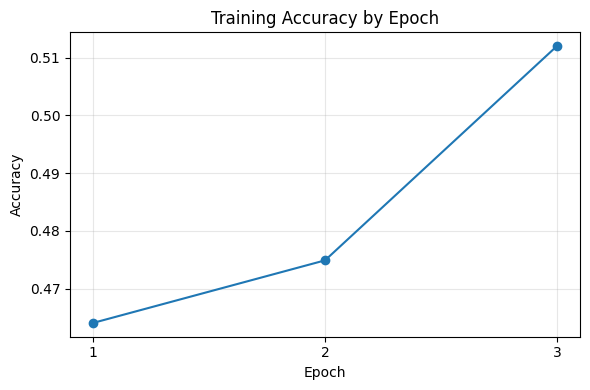

In [23]:
# 1. Training accuracy across epochs
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(epochs, training_history_df["Train Accuracy"], marker="o", color="tab:blue")
ax.set_title("Training Accuracy by Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_xticks(list(epochs))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

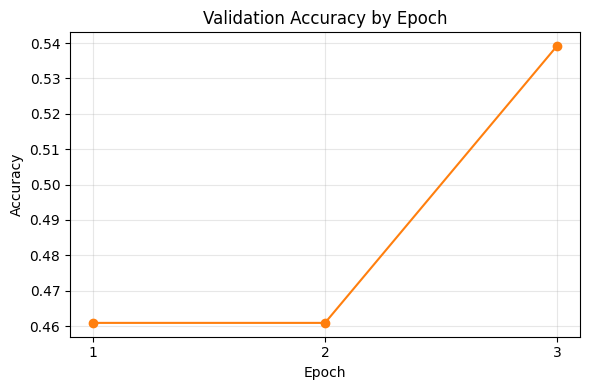

In [24]:
# 2. Validation accuracy across epochs
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(epochs, training_history_df["Validation Accuracy"], marker="o", color="tab:orange")
ax.set_title("Validation Accuracy by Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_xticks(list(epochs))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

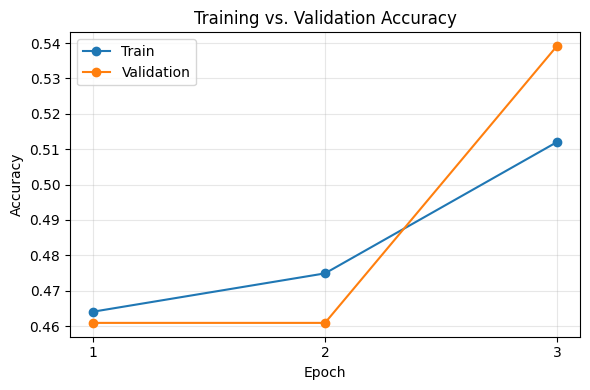

In [25]:
# 3. Training vs. validation accuracy
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(epochs, training_history_df["Train Accuracy"], marker="o", label="Train")
ax.plot(epochs, training_history_df["Validation Accuracy"], marker="o", label="Validation")
ax.set_title("Training vs. Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_xticks(list(epochs))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

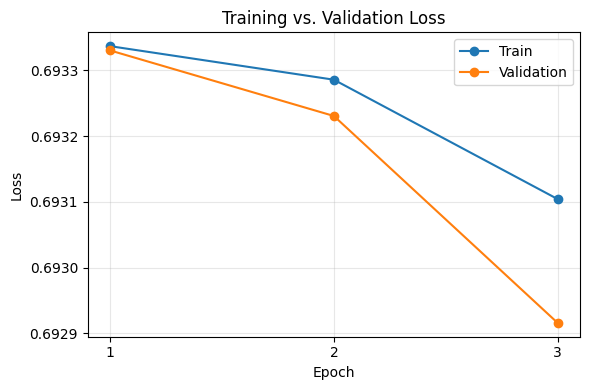

In [26]:
# 4. Training vs. validation loss
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(epochs, training_history_df["Train Loss"], marker="o", label="Train")
ax.plot(epochs, training_history_df["Validation Loss"], marker="o", label="Validation")
ax.set_title("Training vs. Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_xticks(list(epochs))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

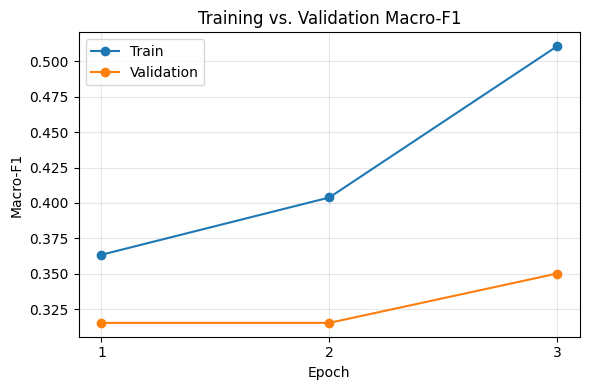

In [27]:
# 5. Training vs. validation macro-F1
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(epochs, training_history_df["Train Macro-F1"], marker="o", label="Train")
ax.plot(epochs, training_history_df["Validation Macro-F1"], marker="o", label="Validation")
ax.set_title("Training vs. Validation Macro-F1")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro-F1")
ax.set_xticks(list(epochs))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 13. LIME explainability (TPU / GPU / CPU compatible)

`predict_proba()`:

* keeps the trained (`best_model`) on the selected device;
* tokenizes and moves every LIME-perturbed batch to that device;
* runs under `torch.no_grad()`, calls `xm.mark_step()` on TPU;
* moves logits to CPU before any NumPy conversion;
* returns columns in the fixed order **[Literal, Simile]**, matching `ID2LABEL` everywhere else
  in the notebook;
* never reloads the model — `best_model` is created once and reused for every perturbation.

**Tamil-specific fix:** LIME's default word-splitting regex is built for whitespace-joined
Latin-script "word characters" and fragments Tamil grapheme clusters (e.g. splits a combining
vowel sign off its base consonant) when used as-is. `split_expression=r"\s+"` makes LIME treat
whitespace-delimited Tamil words as the atomic units it perturbs, matching how the data is
already tokenized into words.


In [28]:
LIME_PREDICTION_BATCH_SIZE = 32
if DEVICE_TYPE == "CPU":
    LIME_PREDICTION_BATCH_SIZE = 8


def predict_proba(texts):
    """Return class probabilities in the fixed order [Literal, Simile].

    The function accepts either one string or an iterable of strings and is
    compatible with TPU, GPU, CPU, and LIME-generated perturbations.
    """
    if isinstance(texts, str):
        texts = [texts]
    else:
        texts = list(texts)

    if len(texts) == 0:
        return np.empty((0, 2), dtype=np.float32)

    # LIME can occasionally create an empty perturbation. Replace it with a
    # harmless tokenizer token rather than allowing tokenization to fail.
    fallback_token = tokenizer.unk_token or tokenizer.pad_token or ""
    clean_texts = [
        str(text) if str(text).strip() else fallback_token
        for text in texts
    ]

    best_model.eval()
    all_probs = []

    with torch.no_grad():
        for start in range(0, len(clean_texts), LIME_PREDICTION_BATCH_SIZE):
            batch_texts = clean_texts[
                start:start + LIME_PREDICTION_BATCH_SIZE
            ]
            encoding = tokenizer(
                batch_texts,
                truncation=True,
                padding=True,
                max_length=MAX_SEQ_LENGTH,
                return_tensors="pt",
            )
            encoding = {
                key: value.to(device)
                for key, value in encoding.items()
            }

            outputs = best_model(**encoding)

            if DEVICE_TYPE == "TPU":
                xm.mark_step()

            probabilities = torch.softmax(
                outputs.logits,
                dim=-1,
            ).detach().cpu().numpy()

            all_probs.append(probabilities)

    output = np.vstack(all_probs)

    if output.shape[1] != 2:
        raise ValueError(
            f"Expected two probability columns, but received {output.shape}."
        )

    return output


# Sanity check: each row must contain [P(Literal), P(Simile)] and sum to 1.
_lime_test_probs = predict_proba([
    test_predictions_df.iloc[0]["line"]
])
print("LIME probability-function check:", _lime_test_probs)
print("Probability sum:", float(_lime_test_probs[0].sum()))
assert np.allclose(_lime_test_probs.sum(axis=1), 1.0, atol=1e-5)

LIME probability-function check: [[0.5003859 0.4996141]]
Probability sum: 1.0


## 13.1 Visual and interactive LIME analysis

The previous version printed LIME weights for three random rows but did not create a visual
explanation. This replacement:

- lets you select a specific test prediction;
- explicitly tells LIME which class to explain;
- draws a horizontal contribution chart;
- shows a structured feature-contribution table;
- compares original, marker-masked, and marker-deleted predictions;
- creates separate visual LIME explanations for the original and masked sentences;
- includes an interactive `ipywidgets` selector with a manual-function fallback.

A positive LIME value supports the class named in the chart title. A negative value opposes it.

## Tamil font support for LIME visualisations

Matplotlib's default font does not contain every Tamil Unicode glyph. This section installs
Noto Tamil fonts, rebuilds Matplotlib's font cache, normalises Tamil text to Unicode NFC form,
and applies the Tamil font explicitly to every LIME y-axis label.

Run this cell before generating the LIME charts. If the fonts are installed for the first time
in a Kaggle session, rerunning the font-configuration cell is normally sufficient. Restart the
session only if Kaggle keeps an old Matplotlib font cache.

In [29]:
# Install the explainability/interface packages and Tamil Unicode fonts.
import importlib.util
import os
import shutil
import subprocess
import sys

for package_name in ["lime", "ipywidgets"]:
    if importlib.util.find_spec(package_name) is None:
        print(f"Installing missing Python package: {package_name}")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name,
        ])

# Noto Sans Tamil provides complete Tamil Unicode glyph coverage.
# This block is safe on Kaggle/Debian and skips installation when apt-get
# is unavailable.
if shutil.which("apt-get") is not None:
    font_check = subprocess.run(
        ["fc-list", ":lang=ta", "family"],
        capture_output=True,
        text=True,
        check=False,
    )

    if "Noto" not in font_check.stdout:
        print("Installing Noto Tamil fonts...")
        subprocess.run(
            ["apt-get", "update", "-qq"],
            check=False,
        )
        subprocess.run(
            [
                "apt-get",
                "install",
                "-y",
                "-qq",
                "fonts-noto-core",
                "fonts-noto-extra",
            ],
            check=False,
        )
        subprocess.run(
            ["fc-cache", "-f"],
            check=False,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
    else:
        print("A Noto Tamil font is already installed.")
else:
    print(
        "apt-get is unavailable. The notebook will use any Tamil font "
        "already installed in the environment."
    )

Installing Noto Tamil fonts...


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Selecting previously unselected package fonts-noto-core.
(Reading database ... 125128 files and directories currently installed.)
Preparing to unpack .../fonts-noto-core_20201225-1build1_all.deb ...
Unpacking fonts-noto-core (20201225-1build1) ...
Selecting previously unselected package fonts-noto-extra.
Preparing to unpack .../fonts-noto-extra_20201225-1build1_all.deb ...
Unpacking fonts-noto-extra (20201225-1build1) ...
Setting up fonts-noto-extra (20201225-1build1) ...
Setting up fonts-noto-core (20201225-1build1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [30]:
# Configure script-aware fonts for Tamil LIME labels and English chart text.
import os
import unicodedata
import warnings
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Rebuild Matplotlib's font manager after installing the operating-system font.
fm._load_fontmanager(try_read_cache=False)

system_fonts = (
    fm.findSystemFonts(fontpaths=None, fontext="ttf")
    + fm.findSystemFonts(fontpaths=None, fontext="otf")
)

preferred_names = [
    "NotoSansTamil-Regular",
    "NotoSansTamil",
    "NotoSerifTamil-Regular",
    "NotoSerifTamil",
    "Latha",
    "Vijaya",
]


def _font_priority(path):
    """Return a lower number for a more desirable Tamil font file."""
    basename = os.path.basename(path).replace(" ", "").lower()
    for index, preferred in enumerate(preferred_names):
        if preferred.replace(" ", "").lower() in basename:
            return index
    if "tamil" in basename:
        return len(preferred_names)
    return len(preferred_names) + 1


tamil_font_paths = sorted(
    {
        path
        for path in system_fonts
        if "tamil" in os.path.basename(path).lower()
    },
    key=_font_priority,
)

# English/numeric chart text should use DejaVu Sans.
ENGLISH_FONT = fm.FontProperties(family="DejaVu Sans")
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False

if tamil_font_paths:
    TAMIL_FONT_PATH = tamil_font_paths[0]
    fm.fontManager.addfont(TAMIL_FONT_PATH)
    TAMIL_FONT = fm.FontProperties(fname=TAMIL_FONT_PATH)
    TAMIL_FONT_NAME = TAMIL_FONT.get_name()

    print("Tamil font selected:", TAMIL_FONT_NAME)
    print("Tamil font file:", TAMIL_FONT_PATH)
else:
    TAMIL_FONT_PATH = None
    TAMIL_FONT = None
    TAMIL_FONT_NAME = None

    warnings.warn(
        "No Tamil font was detected. Run the font-installation cell again "
        "or restart the Kaggle session, then rerun this cell.",
        RuntimeWarning,
    )


def normalise_tamil_text(value):
    """Normalise Tamil/Unicode text before rendering it in Matplotlib."""
    return unicodedata.normalize("NFC", str(value))


def contains_tamil(value):
    """Return True when a string contains at least one Tamil Unicode character."""
    text = normalise_tamil_text(value)
    return any("\u0B80" <= char <= "\u0BFF" for char in text)


def font_for_text(value):
    """Choose Tamil or English font according to the text's script."""
    if contains_tamil(value) and TAMIL_FONT is not None:
        return TAMIL_FONT
    return ENGLISH_FONT


def apply_script_aware_yticklabels(ax, labels, fontsize=12):
    """Apply Tamil font only to Tamil labels and English font to ASCII labels."""
    labels = [normalise_tamil_text(label) for label in labels]
    ax.set_yticklabels(labels, fontsize=fontsize)

    for tick_label, label in zip(ax.get_yticklabels(), labels):
        tick_label.set_fontproperties(font_for_text(label))
        tick_label.set_fontsize(fontsize)

    return ax.get_yticklabels()

Tamil font selected: Noto Sans Tamil
Tamil font file: /usr/share/fonts/truetype/noto/NotoSansTamil-Regular.ttf


/tmp/ipykernel_23/2897499325.py:37: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Tamil.
  plt.tight_layout()
/tmp/ipykernel_23/2897499325.py:37: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Tamil.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Tamil.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Tamil.
  fig.canvas.print_figure(bytes_io, **kw)


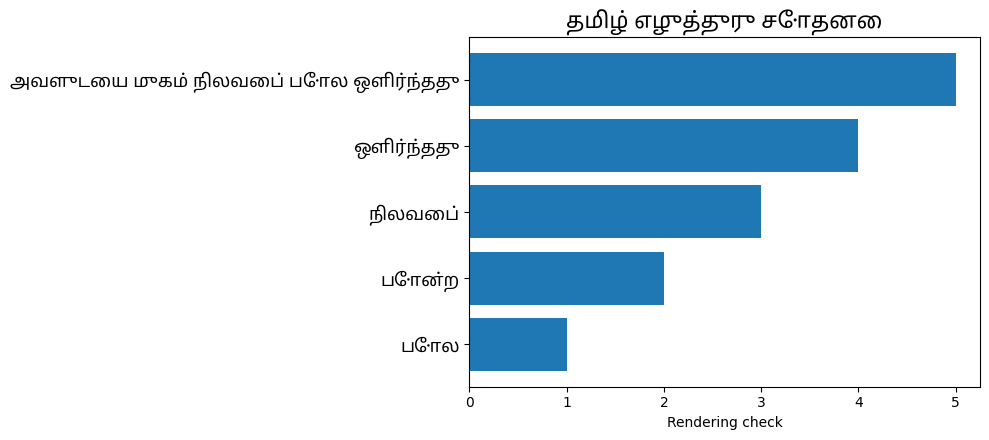

In [31]:
# Tamil rendering test. Tamil labels should appear correctly and English
# labels should no longer trigger missing-glyph warnings.
_tamil_test_labels = [
    "போல",
    "போன்ற",
    "நிலவைப்",
    "ஒளிர்ந்தது",
    "அவளுடைய முகம் நிலவைப் போல ஒளிர்ந்தது",
]
_tamil_test_labels = [
    normalise_tamil_text(label)
    for label in _tamil_test_labels
]

fig, ax = plt.subplots(figsize=(10, 4.5))
positions = list(range(len(_tamil_test_labels)))

ax.barh(positions, [1, 2, 3, 4, 5])
ax.set_yticks(positions)
apply_script_aware_yticklabels(
    ax,
    _tamil_test_labels,
    fontsize=13,
)

title_text = normalise_tamil_text("தமிழ் எழுத்துரு சோதனை")
ax.set_title(
    title_text,
    fontproperties=font_for_text(title_text),
    fontsize=16,
)
ax.set_xlabel(
    "Rendering check",
    fontproperties=ENGLISH_FONT,
)

plt.tight_layout()
plt.show()

In [32]:
from lime.lime_text import LimeTextExplainer
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

LIME_CLASS_NAMES = ["Literal", "Simile"]
LIME_DEFAULT_NUM_SAMPLES = 1000
LIME_DEFAULT_NUM_FEATURES = 10

lime_explainer = LimeTextExplainer(
    class_names=LIME_CLASS_NAMES,
    split_expression=r"\s+",
    bow=True,
    random_state=RANDOM_SEED,
)


def _match_marker_in_feature(feature):
    """Return the first known marker found inside a LIME feature."""
    feature_text = str(feature)
    for marker in SIMILE_MARKERS_SORTED:
        if marker in feature_text:
            return marker
    return ""


def build_lime_feature_table(explanation, target_label):
    """Convert a LIME explanation into a research-friendly dataframe."""
    feature_rows = explanation.as_list(label=int(target_label))

    rows = []
    for rank, (feature, weight) in enumerate(feature_rows, start=1):
        weight = float(weight)
        rows.append({
            "rank": rank,
            "feature": feature,
            "lime_weight": weight,
            "absolute_weight": abs(weight),
            "direction": (
                f"Supports {ID2LABEL[int(target_label)]}"
                if weight >= 0
                else f"Opposes {ID2LABEL[int(target_label)]}"
            ),
            "matched_marker": _match_marker_in_feature(feature),
        })

    table = pd.DataFrame(rows)
    if not table.empty:
        table = table.sort_values(
            "absolute_weight",
            ascending=False,
        ).reset_index(drop=True)
        table["rank"] = np.arange(1, len(table) + 1)
    return table


def plot_lime_feature_table(feature_table, title):
    """Draw a horizontal LIME chart with script-aware font selection."""
    if feature_table.empty:
        print("No LIME features were returned for this sentence.")
        return None

    plot_df = feature_table.sort_values(
        "lime_weight",
        ascending=True,
    ).reset_index(drop=True)

    feature_labels = [
        normalise_tamil_text(feature)
        for feature in plot_df["feature"].astype(str).tolist()
    ]
    clean_title = normalise_tamil_text(title)

    figure_height = max(4.5, 0.58 * len(plot_df))
    fig, ax = plt.subplots(figsize=(10.5, figure_height))

    y_positions = np.arange(len(plot_df))
    ax.barh(
        y_positions,
        plot_df["lime_weight"].to_numpy(),
    )
    ax.set_yticks(y_positions)
    apply_script_aware_yticklabels(
        ax,
        feature_labels,
        fontsize=12,
    )

    # LIME titles and axis labels are English, so use an English-capable font.
    ax.set_title(
        clean_title,
        fontproperties=font_for_text(clean_title),
        fontsize=14,
    )
    ax.axvline(0.0, linewidth=1)
    ax.set_xlabel(
        "LIME contribution to the explained class",
        fontproperties=ENGLISH_FONT,
    )
    ax.set_ylabel(
        "Tamil word / feature",
        fontproperties=ENGLISH_FONT,
    )
    ax.grid(axis="x", alpha=0.25)
    ax.margins(y=0.04)

    plt.tight_layout()
    plt.show()
    return fig


def explain_text_visually(
    text,
    target_label=None,
    num_samples=LIME_DEFAULT_NUM_SAMPLES,
    num_features=LIME_DEFAULT_NUM_FEATURES,
    title_prefix="LIME explanation",
):
    """Generate probabilities, a LIME table, and a visible matplotlib chart.

    When target_label is None, LIME explains the model's predicted class.
    Set target_label=1 to explain evidence for the Simile class consistently.
    """
    probabilities = predict_proba([text])[0]
    predicted_label = int(np.argmax(probabilities))

    if target_label is None:
        target_label = predicted_label
    target_label = int(target_label)

    explanation = lime_explainer.explain_instance(
        text_instance=str(text),
        classifier_fn=predict_proba,
        labels=[target_label],
        num_features=int(num_features),
        num_samples=int(num_samples),
    )

    feature_table = build_lime_feature_table(
        explanation,
        target_label,
    )

    title = (
        f"{title_prefix}: evidence for "
        f"{ID2LABEL[target_label]}"
    )
    figure = plot_lime_feature_table(
        feature_table,
        title,
    )

    return {
        "text": str(text),
        "probabilities": probabilities,
        "predicted_label": predicted_label,
        "predicted_class": ID2LABEL[predicted_label],
        "target_label": target_label,
        "target_class": ID2LABEL[target_label],
        "explanation": explanation,
        "feature_table": feature_table,
        "figure": figure,
    }


def explain_selected_test_prediction(
    sample_id,
    target_mode="Predicted class",
    num_samples=LIME_DEFAULT_NUM_SAMPLES,
    num_features=LIME_DEFAULT_NUM_FEATURES,
):
    """Display prediction metadata and a visual LIME explanation for one row."""
    matches = test_predictions_df[
        test_predictions_df["sample_id"].astype(str) == str(sample_id)
    ]

    if matches.empty:
        raise KeyError(
            f"Unknown sample_id: {sample_id}. "
            "Choose an ID from test_predictions_df."
        )

    row = matches.iloc[0]

    if target_mode == "Simile class":
        target_label = 1
    elif target_mode == "Literal class":
        target_label = 0
    else:
        target_label = int(row["predicted_label"])

    display(Markdown(
        f"""
### Selected test prediction

**Sample ID:** `{row['sample_id']}`  
**Sentence:** {row['line']}  
**Actual class:** {row['actual_class']}  
**Predicted class:** {row['predicted_class']}  
**Confidence:** {row['confidence']:.4f}  
**Literal probability:** {row['literal_probability']:.4f}  
**Simile probability:** {row['simile_probability']:.4f}  
**Correct:** {bool(row['correct'])}  
**Marker detected:** {row['marker_text'] if row['marker_present'] else 'None'}  
**Linguistic group:** {row['linguistic_group']}  
**LIME target:** {ID2LABEL[target_label]}
"""
    ))

    result = explain_text_visually(
        text=row["line"],
        target_label=target_label,
        num_samples=num_samples,
        num_features=num_features,
        title_prefix=f"Sample {row['sample_id']}",
    )

    display(result["feature_table"])
    return result

In [33]:
def mask_all_detected_markers(text):
    """Replace every configured marker in a sentence with MuRIL's mask token."""
    mask_token = tokenizer.mask_token
    if not mask_token:
        raise ValueError(
            "The active tokenizer does not define a mask token."
        )

    output = str(text)
    found_markers = []

    for marker in SIMILE_MARKERS_SORTED:
        if marker in output:
            found_markers.append(marker)
            output = output.replace(marker, f" {mask_token} ")

    output = " ".join(output.split())
    return output, found_markers


def delete_all_detected_markers(text):
    """Delete every configured marker from a sentence."""
    output = str(text)
    found_markers = []

    for marker in SIMILE_MARKERS_SORTED:
        if marker in output:
            found_markers.append(marker)
            output = output.replace(marker, " ")

    output = " ".join(output.split())
    return output, found_markers


def _resolve_comparison_target(
    target_mode,
    original_predicted_label,
    current_predicted_label,
):
    """Choose which class LIME should explain for each sentence variant."""
    if target_mode == "Simile class":
        return 1
    if target_mode == "Literal class":
        return 0
    if target_mode == "Original predicted class":
        return int(original_predicted_label)
    return int(current_predicted_label)


def compare_original_masked_deleted(
    sample_id,
    target_mode="Original predicted class",
    num_samples=LIME_DEFAULT_NUM_SAMPLES,
    num_features=LIME_DEFAULT_NUM_FEATURES,
    explain_masked=True,
):
    """Compare prediction probabilities and LIME before/after marker removal."""
    matches = test_predictions_df[
        test_predictions_df["sample_id"].astype(str) == str(sample_id)
    ]

    if matches.empty:
        raise KeyError(f"Unknown sample_id: {sample_id}")

    row = matches.iloc[0]
    original_text = str(row["line"])
    masked_text, found_markers = mask_all_detected_markers(
        original_text
    )
    deleted_text, _ = delete_all_detected_markers(
        original_text
    )

    if not found_markers:
        display(Markdown(
            "### Marker comparison\n"
            "No configured simile marker was detected in this sentence."
        ))
        return None

    versions = ["Original", "Masked", "Deleted"]
    texts = [original_text, masked_text, deleted_text]
    probabilities = predict_proba(texts)
    predictions = np.argmax(probabilities, axis=1)
    confidences = probabilities[
        np.arange(len(predictions)),
        predictions,
    ]

    comparison_df = pd.DataFrame({
        "version": versions,
        "sentence": texts,
        "literal_probability": probabilities[:, 0],
        "simile_probability": probabilities[:, 1],
        "predicted_class": [
            ID2LABEL[int(label)]
            for label in predictions
        ],
        "confidence": confidences,
        "class_changed_from_original": [
            bool(label != predictions[0])
            for label in predictions
        ],
    })

    simile_drop_masked = (
        probabilities[0, 1] - probabilities[1, 1]
    )
    simile_drop_deleted = (
        probabilities[0, 1] - probabilities[2, 1]
    )

    display(Markdown(
        f"""
### Original versus marker-removed prediction

**Sample ID:** `{row['sample_id']}`  
**Detected marker(s):** {', '.join(found_markers)}  
**Simile-probability drop after masking:** {simile_drop_masked:.4f}  
**Simile-probability drop after deletion:** {simile_drop_deleted:.4f}
"""
    ))
    display(comparison_df)

    original_target = _resolve_comparison_target(
        target_mode,
        original_predicted_label=predictions[0],
        current_predicted_label=predictions[0],
    )

    display(Markdown("### LIME — original sentence"))
    original_result = explain_text_visually(
        original_text,
        target_label=original_target,
        num_samples=num_samples,
        num_features=num_features,
        title_prefix="Original sentence",
    )
    display(original_result["feature_table"])

    masked_result = None
    if explain_masked:
        masked_target = _resolve_comparison_target(
            target_mode,
            original_predicted_label=predictions[0],
            current_predicted_label=predictions[1],
        )
        display(Markdown("### LIME — marker-masked sentence"))
        masked_result = explain_text_visually(
            masked_text,
            target_label=masked_target,
            num_samples=num_samples,
            num_features=num_features,
            title_prefix="Marker-masked sentence",
        )
        display(masked_result["feature_table"])

    return {
        "comparison_table": comparison_df,
        "found_markers": found_markers,
        "simile_probability_drop_after_masking": float(
            simile_drop_masked
        ),
        "simile_probability_drop_after_deletion": float(
            simile_drop_deleted
        ),
        "original_lime": original_result,
        "masked_lime": masked_result,
    }

In [34]:
try:
    import ipywidgets as widgets
    from IPython.display import clear_output

    _WIDGETS_AVAILABLE = True
except ImportError:
    _WIDGETS_AVAILABLE = False
    print(
        "ipywidgets is unavailable. Use "
        "explain_selected_test_prediction(sample_id) manually."
    )


def _filter_test_predictions(
    prediction_status="All Predictions",
    marker_condition="All",
    linguistic_group="All Groups",
):
    """Filter the test prediction table for interactive selection."""
    filtered = test_predictions_df.copy()

    if prediction_status == "Incorrect Predictions":
        filtered = filtered[~filtered["correct"]]
    elif prediction_status == "Correct Predictions":
        filtered = filtered[filtered["correct"]]
    elif prediction_status == "False Positives":
        filtered = filtered[
            (filtered["actual_label"] == 0)
            & (filtered["predicted_label"] == 1)
        ]
    elif prediction_status == "False Negatives":
        filtered = filtered[
            (filtered["actual_label"] == 1)
            & (filtered["predicted_label"] == 0)
        ]
    elif prediction_status == "True Positives":
        filtered = filtered[
            (filtered["actual_label"] == 1)
            & (filtered["predicted_label"] == 1)
        ]
    elif prediction_status == "True Negatives":
        filtered = filtered[
            (filtered["actual_label"] == 0)
            & (filtered["predicted_label"] == 0)
        ]

    if marker_condition == "Marker Present":
        filtered = filtered[filtered["marker_present"]]
    elif marker_condition == "Marker Absent":
        filtered = filtered[~filtered["marker_present"]]

    if linguistic_group != "All Groups":
        filtered = filtered[
            filtered["linguistic_group"] == linguistic_group
        ]

    return filtered.reset_index(drop=True)


if _WIDGETS_AVAILABLE:
    prediction_status_widget = widgets.Dropdown(
        options=[
            "All Predictions",
            "Incorrect Predictions",
            "Correct Predictions",
            "False Positives",
            "False Negatives",
            "True Positives",
            "True Negatives",
        ],
        value="Incorrect Predictions",
        description="Prediction:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="360px"),
    )

    marker_condition_widget = widgets.Dropdown(
        options=[
            "All",
            "Marker Present",
            "Marker Absent",
        ],
        value="All",
        description="Marker:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="300px"),
    )

    linguistic_group_widget = widgets.Dropdown(
        options=[
            "All Groups",
            "S+M",
            "S-M",
            "L+M",
            "L-M",
        ],
        value="All Groups",
        description="Group:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="260px"),
    )

    sample_widget = widgets.Dropdown(
        options=[],
        description="Sample:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="95%"),
    )

    target_mode_widget = widgets.Dropdown(
        options=[
            "Predicted class",
            "Original predicted class",
            "Simile class",
            "Literal class",
        ],
        value="Predicted class",
        description="LIME target:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="330px"),
    )

    num_samples_widget = widgets.IntSlider(
        value=LIME_DEFAULT_NUM_SAMPLES,
        min=200,
        max=5000,
        step=200,
        description="Perturbations:",
        continuous_update=False,
        style={"description_width": "initial"},
        layout=widgets.Layout(width="420px"),
    )

    num_features_widget = widgets.IntSlider(
        value=LIME_DEFAULT_NUM_FEATURES,
        min=4,
        max=20,
        step=1,
        description="Features:",
        continuous_update=False,
        style={"description_width": "initial"},
        layout=widgets.Layout(width="360px"),
    )

    show_button = widgets.Button(
        description="Show visual LIME",
        button_style="primary",
        icon="bar-chart",
    )

    compare_button = widgets.Button(
        description="Compare marker masking",
        button_style="warning",
        icon="exchange",
    )

    filter_summary_output = widgets.Output()
    explanation_output = widgets.Output()


    def _refresh_sample_options(*_):
        filtered = _filter_test_predictions(
            prediction_status_widget.value,
            marker_condition_widget.value,
            linguistic_group_widget.value,
        )

        options = []
        for _, row in filtered.iterrows():
            sentence_preview = str(row["line"])
            if len(sentence_preview) > 75:
                sentence_preview = sentence_preview[:72] + "..."

            label = (
                f"{row['sample_id']} | "
                f"A:{row['actual_class']} "
                f"P:{row['predicted_class']} | "
                f"{sentence_preview}"
            )
            options.append((label, str(row["sample_id"])))

        sample_widget.options = options
        sample_widget.value = options[0][1] if options else None

        with filter_summary_output:
            clear_output(wait=True)
            print(f"Matching test predictions: {len(filtered)}")
            if len(filtered) > 0:
                display(
                    filtered[
                        [
                            "sample_id",
                            "line",
                            "actual_class",
                            "predicted_class",
                            "confidence",
                            "marker_text",
                            "linguistic_group",
                        ]
                    ].head(15)
                )
            else:
                print("No rows match the current filters.")


    def _show_selected_lime(_):
        with explanation_output:
            clear_output(wait=True)

            if sample_widget.value is None:
                print("Select filters that return at least one sample.")
                return

            mode = target_mode_widget.value
            if mode == "Original predicted class":
                mode = "Predicted class"

            explain_selected_test_prediction(
                sample_id=sample_widget.value,
                target_mode=mode,
                num_samples=num_samples_widget.value,
                num_features=num_features_widget.value,
            )


    def _show_marker_comparison(_):
        with explanation_output:
            clear_output(wait=True)

            if sample_widget.value is None:
                print("Select filters that return at least one sample.")
                return

            comparison_mode = target_mode_widget.value
            if comparison_mode == "Predicted class":
                comparison_mode = "Original predicted class"

            compare_original_masked_deleted(
                sample_id=sample_widget.value,
                target_mode=comparison_mode,
                num_samples=num_samples_widget.value,
                num_features=num_features_widget.value,
                explain_masked=True,
            )


    for control in [
        prediction_status_widget,
        marker_condition_widget,
        linguistic_group_widget,
    ]:
        control.observe(
            _refresh_sample_options,
            names="value",
        )

    show_button.on_click(_show_selected_lime)
    compare_button.on_click(_show_marker_comparison)

    _refresh_sample_options()

    display(Markdown(
        """
## Interactive LIME prediction explorer

Use the filters to select a test prediction.  
- **Show visual LIME** explains the selected sentence.
- **Compare marker masking** compares the original, masked and deleted variants and displays LIME charts for the original and masked versions.
"""
    ))

    display(widgets.VBox([
        widgets.HBox([
            prediction_status_widget,
            marker_condition_widget,
            linguistic_group_widget,
        ]),
        sample_widget,
        widgets.HBox([
            target_mode_widget,
            num_samples_widget,
            num_features_widget,
        ]),
        widgets.HBox([
            show_button,
            compare_button,
        ]),
        filter_summary_output,
        explanation_output,
    ]))


## Interactive LIME prediction explorer

Use the filters to select a test prediction.  
- **Show visual LIME** explains the selected sentence.
- **Compare marker masking** compares the original, masked and deleted variants and displays LIME charts for the original and masked versions.


### Manual fallback

When the widget does not render, obtain an available ID with:

```python
test_predictions_df[
    ["sample_id", "line", "actual_class", "predicted_class", "marker_text"]
].head(20)
```

Then run one of these:

```python
explain_selected_test_prediction(
    sample_id="test_0",
    target_mode="Predicted class",
    num_samples=1000,
    num_features=10,
)
```

```python
compare_original_masked_deleted(
    sample_id="test_0",
    target_mode="Original predicted class",
    num_samples=1000,
    num_features=10,
)
```

For direct comparison across the original and masked versions, keeping
`target_mode="Original predicted class"` is usually the clearest choice because both charts
explain evidence for the same class. Choose `"Simile class"` when the research question is
specifically about evidence for class 1 in both variants.

## 14. Structured export of marker comparisons and LIME results

This section creates a reproducible folder structure and saves:

- train, validation, and test predictions;
- S+M, S−M, L+M, and L−M prediction subsets;
- marker-present versus marker-absent metrics;
- simile-with-marker versus markerless-simile comparisons;
- literal-with-marker versus literal-without-marker comparisons;
- per-group confusion matrices;
- original, marker-masked, and marker-deleted predictions;
- LIME feature tables, PNG charts, HTML explanations, and JSON metadata;
- combined LIME feature and sample-level summary files;
- a manifest listing every exported artifact.

The default LIME mode is `representative`: it exports a configurable number of examples
from every linguistic group, prioritising errors and low-confidence predictions. Change
`LIME_EXPORT_MODE` to `"all"` to generate LIME outputs for every test example.

> **Rerun safety:** If a previous dataframe is missing from memory, the export setup reloads it from the corresponding CSV in `OUTPUT_DIR`. The aggregation dataframe is recognised under both `three_epoch_aggregate_df` and `three_epoch_aggregate_metrics_df`.


In [35]:
from pathlib import Path
import json
import shutil
import hashlib
import math
import traceback
from datetime import datetime, timezone

# Root folder for all research artifacts.
RESEARCH_EXPORT_ROOT = Path(
    OUTPUT_DIR
) / "tamil_simile_research_outputs"

EXPORT_PATHS = {
    "root": RESEARCH_EXPORT_ROOT,
    "model": RESEARCH_EXPORT_ROOT / "01_model",
    "metrics": RESEARCH_EXPORT_ROOT / "02_metrics",
    "predictions": RESEARCH_EXPORT_ROOT / "03_predictions",
    "marker_comparisons": RESEARCH_EXPORT_ROOT / "04_marker_comparisons",
    "lime": RESEARCH_EXPORT_ROOT / "05_lime",
    "figures": RESEARCH_EXPORT_ROOT / "06_figures",
    "reports": RESEARCH_EXPORT_ROOT / "07_reports",
    "logs": RESEARCH_EXPORT_ROOT / "08_logs",
}

GROUP_FOLDER_NAMES = {
    "S+M": "S_plus_M_simile_with_marker",
    "S-M": "S_minus_M_markerless_simile",
    "L+M": "L_plus_M_literal_with_marker",
    "L-M": "L_minus_M_literal_without_marker",
}

for folder in EXPORT_PATHS.values():
    folder.mkdir(parents=True, exist_ok=True)

for group_folder in GROUP_FOLDER_NAMES.values():
    (EXPORT_PATHS["marker_comparisons"] / group_folder).mkdir(
        parents=True,
        exist_ok=True,
    )
    (EXPORT_PATHS["lime"] / group_folder).mkdir(
        parents=True,
        exist_ok=True,
    )

(EXPORT_PATHS["figures"] / "training").mkdir(
    parents=True,
    exist_ok=True,
)
(EXPORT_PATHS["figures"] / "marker_comparisons").mkdir(
    parents=True,
    exist_ok=True,
)
(EXPORT_PATHS["figures"] / "lime").mkdir(
    parents=True,
    exist_ok=True,
)


def _json_safe(value):
    """Convert NumPy/Pandas values into JSON-serialisable Python objects."""
    if value is None:
        return None
    if isinstance(value, (np.bool_, bool)):
        return bool(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        if math.isnan(float(value)) or math.isinf(float(value)):
            return None
        return float(value)
    if isinstance(value, (pd.Timestamp,)):
        return value.isoformat()
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {
            str(key): _json_safe(item)
            for key, item in value.items()
        }
    if isinstance(value, (list, tuple, set, np.ndarray)):
        return [_json_safe(item) for item in value]
    return value


def save_json(data, path):
    """Save JSON using UTF-8 so Tamil text is preserved."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(
        json.dumps(
            _json_safe(data),
            ensure_ascii=False,
            indent=2,
        ),
        encoding="utf-8",
    )


def safe_file_component(value):
    """Create a filename-safe component while preserving readability."""
    text = str(value).strip()
    cleaned = "".join(
        char if char.isalnum() or char in {"-", "_"} else "_"
        for char in text
    )
    cleaned = cleaned.strip("_")
    return cleaned or "unnamed"


def get_dataframe_or_load(variable_names, csv_filename):
    """Return an existing dataframe or reload it from OUTPUT_DIR.

    This makes the export section safe when Kaggle has retained earlier CSV
    outputs but some notebook variables were cleared or named differently.
    """
    if isinstance(variable_names, str):
        variable_names = [variable_names]

    for variable_name in variable_names:
        value = globals().get(variable_name)
        if isinstance(value, pd.DataFrame):
            return value

    csv_path = Path(OUTPUT_DIR) / csv_filename
    if csv_path.exists():
        print(
            f"Reloading {csv_filename} because none of "
            f"{variable_names} exists in memory."
        )
        return pd.read_csv(csv_path)

    raise RuntimeError(
        "Required dataframe is unavailable. Run the earlier notebook cell "
        f"that creates one of {variable_names}, or confirm that this file "
        f"exists: {csv_path}"
    )


# Resolve every primary dataframe safely.
export_training_history_df = get_dataframe_or_load(
    "training_history_df",
    "training_history.csv",
)
export_three_epoch_aggregate_df = get_dataframe_or_load(
    [
        "three_epoch_aggregate_df",
        "three_epoch_aggregate_metrics_df",
    ],
    "three_epoch_aggregate_metrics.csv",
)
export_final_split_metrics_df = get_dataframe_or_load(
    "final_split_metrics_df",
    "final_split_metrics.csv",
)
export_marker_group_metrics_df = get_dataframe_or_load(
    "marker_group_metrics_df",
    "marker_group_metrics.csv",
)

export_train_predictions_df = get_dataframe_or_load(
    "train_predictions_df",
    "train_predictions.csv",
)
export_validation_predictions_df = get_dataframe_or_load(
    "validation_predictions_df",
    "validation_predictions.csv",
)
export_test_predictions_df = get_dataframe_or_load(
    "test_predictions_df",
    "test_predictions.csv",
)
export_all_split_predictions_df = get_dataframe_or_load(
    "all_split_predictions_df",
    "all_split_predictions.csv",
)


# Save the primary notebook dataframes into the structured folders.
export_training_history_df.to_csv(
    EXPORT_PATHS["metrics"] / "training_history.csv",
    index=False,
)
export_three_epoch_aggregate_df.to_csv(
    EXPORT_PATHS["metrics"] / "three_epoch_aggregate_metrics.csv",
    index=False,
)
export_final_split_metrics_df.to_csv(
    EXPORT_PATHS["metrics"] / "final_split_metrics.csv",
    index=False,
)
export_marker_group_metrics_df.to_csv(
    EXPORT_PATHS["metrics"] / "marker_group_metrics.csv",
    index=False,
)

export_train_predictions_df.to_csv(
    EXPORT_PATHS["predictions"] / "train_predictions.csv",
    index=False,
)
export_validation_predictions_df.to_csv(
    EXPORT_PATHS["predictions"] / "validation_predictions.csv",
    index=False,
)
export_test_predictions_df.to_csv(
    EXPORT_PATHS["predictions"] / "test_predictions.csv",
    index=False,
)
export_all_split_predictions_df.to_csv(
    EXPORT_PATHS["predictions"] / "all_split_predictions.csv",
    index=False,
)

# Preserve the standard variable names for all later export cells.
training_history_df = export_training_history_df
three_epoch_aggregate_df = export_three_epoch_aggregate_df
three_epoch_aggregate_metrics_df = export_three_epoch_aggregate_df
final_split_metrics_df = export_final_split_metrics_df
marker_group_metrics_df = export_marker_group_metrics_df
train_predictions_df = export_train_predictions_df
validation_predictions_df = export_validation_predictions_df
test_predictions_df = export_test_predictions_df
all_split_predictions_df = export_all_split_predictions_df

# Avoid unnecessarily duplicating a large model by saving its source location.
model_reference = {
    "best_checkpoint_directory": str(BEST_CHECKPOINT_DIR),
    "base_model": MODEL_NAME,
    "selected_accelerator": DEVICE_TYPE,
    "created_utc": datetime.now(timezone.utc).isoformat(),
}
save_json(
    model_reference,
    EXPORT_PATHS["model"] / "model_reference.json",
)

print("Structured research export root:")
print(RESEARCH_EXPORT_ROOT)

Structured research export root:
/kaggle/working/tamil_simile_research_outputs


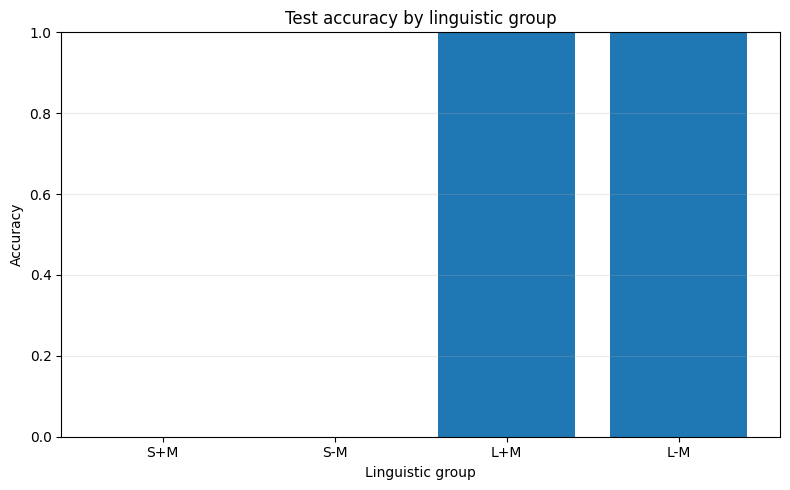

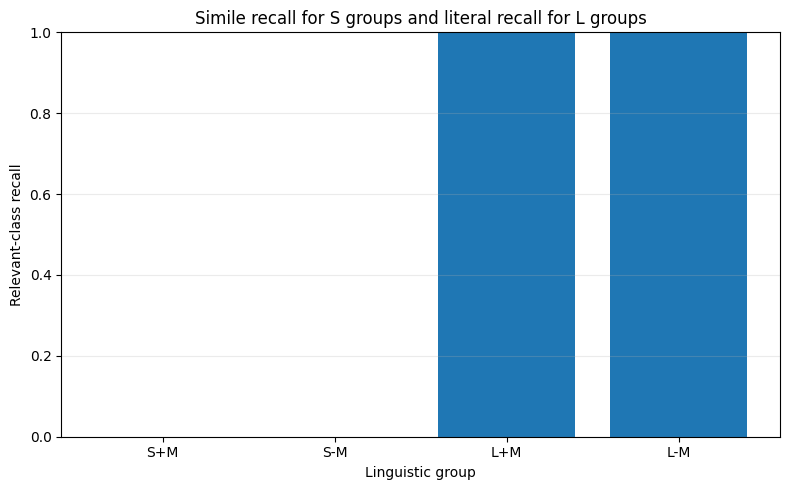

Saved all group-level prediction comparisons.


,comparison_group,number_of_examples,correct_predictions,incorrect_predictions,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,mean_confidence,simile_recall,literal_recall
0,S+M,436,0,436,0.0,0.0,0.0,0.0,0.0,0.500454,0.0,NaN
1,S-M,136,0,136,0.0,0.0,0.0,0.0,0.0,0.500626,0.0,NaN
2,L+M,100,100,0,1.0,1.0,0.5,0.5,0.5,0.500602,NaN,1.0
3,L-M,568,568,0,1.0,1.0,0.5,0.5,0.5,0.500644,NaN,1.0


In [36]:
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support,
    recall_score,
)


def prediction_subset_metrics(subset, label):
    """Calculate descriptive metrics for a prediction subset."""
    n = len(subset)
    if n == 0:
        return {
            "comparison_group": label,
            "number_of_examples": 0,
            "correct_predictions": 0,
            "incorrect_predictions": 0,
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "macro_precision": np.nan,
            "macro_recall": np.nan,
            "macro_f1": np.nan,
            "mean_confidence": np.nan,
            "simile_recall": np.nan,
            "literal_recall": np.nan,
        }

    labels = subset["actual_label"].to_numpy()
    predictions = subset["predicted_label"].to_numpy()
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        labels=[0, 1],
        average="macro",
        zero_division=0,
    )

    # Calculate class-specific recalls only when the true class is present.
    simile_recall = (
        recall_score(
            labels,
            predictions,
            pos_label=1,
            zero_division=0,
        )
        if np.any(labels == 1)
        else np.nan
    )
    literal_recall = (
        recall_score(
            labels,
            predictions,
            pos_label=0,
            zero_division=0,
        )
        if np.any(labels == 0)
        else np.nan
    )

    class_recalls = []
    for class_label in [0, 1]:
        class_mask = labels == class_label
        if np.any(class_mask):
            class_recalls.append(
                float(
                    np.mean(
                        predictions[class_mask] == class_label
                    )
                )
            )

    return {
        "comparison_group": label,
        "number_of_examples": int(n),
        "correct_predictions": int(subset["correct"].sum()),
        "incorrect_predictions": int((~subset["correct"]).sum()),
        "accuracy": float(subset["correct"].mean()),
        "balanced_accuracy": (
            float(np.mean(class_recalls))
            if class_recalls
            else np.nan
        ),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
        "mean_confidence": float(subset["confidence"].mean()),
        "simile_recall": simile_recall,
        "literal_recall": literal_recall,
    }


# Save every test example into its linguistic-group folder.
for group, folder_name in GROUP_FOLDER_NAMES.items():
    group_df = test_predictions_df[
        test_predictions_df["linguistic_group"] == group
    ].copy()

    group_folder = (
        EXPORT_PATHS["marker_comparisons"] / folder_name
    )
    group_df.to_csv(
        group_folder / "all_predictions.csv",
        index=False,
    )
    group_df[group_df["correct"]].to_csv(
        group_folder / "correct_predictions.csv",
        index=False,
    )
    group_df[~group_df["correct"]].to_csv(
        group_folder / "incorrect_predictions.csv",
        index=False,
    )

    matrix = confusion_matrix(
        group_df["actual_label"],
        group_df["predicted_label"],
        labels=[0, 1],
    ) if len(group_df) else np.zeros((2, 2), dtype=int)

    pd.DataFrame(
        matrix,
        index=["Actual_Literal", "Actual_Simile"],
        columns=["Predicted_Literal", "Predicted_Simile"],
    ).to_csv(
        group_folder / "confusion_matrix.csv",
    )


# Comparison table 1: all four linguistic groups.
four_group_comparison_rows = []
for group in ["S+M", "S-M", "L+M", "L-M"]:
    subset = test_predictions_df[
        test_predictions_df["linguistic_group"] == group
    ]
    four_group_comparison_rows.append(
        prediction_subset_metrics(subset, group)
    )

four_group_comparison_df = pd.DataFrame(
    four_group_comparison_rows
)
four_group_comparison_df.to_csv(
    EXPORT_PATHS["metrics"]
    / "test_four_group_comparison.csv",
    index=False,
)


# Comparison table 2: marker-present versus marker-absent, regardless of label.
marker_presence_rows = []
for marker_value, label in [
    (True, "Marker Present"),
    (False, "Marker Absent"),
]:
    subset = test_predictions_df[
        test_predictions_df["marker_present"] == marker_value
    ]
    marker_presence_rows.append(
        prediction_subset_metrics(subset, label)
    )

marker_presence_comparison_df = pd.DataFrame(
    marker_presence_rows
)
marker_presence_comparison_df.to_csv(
    EXPORT_PATHS["metrics"]
    / "marker_present_vs_absent_comparison.csv",
    index=False,
)


# Comparison table 3: simile marker effect, S+M versus S-M.
simile_marker_comparison_df = four_group_comparison_df[
    four_group_comparison_df["comparison_group"].isin(
        ["S+M", "S-M"]
    )
].copy()
simile_marker_comparison_df.to_csv(
    EXPORT_PATHS["metrics"]
    / "simile_with_marker_vs_markerless.csv",
    index=False,
)


# Comparison table 4: literal marker effect, L+M versus L-M.
literal_marker_comparison_df = four_group_comparison_df[
    four_group_comparison_df["comparison_group"].isin(
        ["L+M", "L-M"]
    )
].copy()
literal_marker_comparison_df.to_csv(
    EXPORT_PATHS["metrics"]
    / "literal_with_marker_vs_without_marker.csv",
    index=False,
)


def _metric_for_group(df, group, metric):
    row = df[df["comparison_group"] == group]
    if row.empty:
        return np.nan
    return float(row.iloc[0][metric])


research_gap_summary = {
    "test_simile_recall_S_plus_M": _metric_for_group(
        four_group_comparison_df,
        "S+M",
        "simile_recall",
    ),
    "test_simile_recall_S_minus_M": _metric_for_group(
        four_group_comparison_df,
        "S-M",
        "simile_recall",
    ),
    "simile_recall_gap_marker_minus_markerless": (
        _metric_for_group(
            four_group_comparison_df,
            "S+M",
            "simile_recall",
        )
        - _metric_for_group(
            four_group_comparison_df,
            "S-M",
            "simile_recall",
        )
    ),
    "test_literal_recall_L_plus_M": _metric_for_group(
        four_group_comparison_df,
        "L+M",
        "literal_recall",
    ),
    "test_literal_recall_L_minus_M": _metric_for_group(
        four_group_comparison_df,
        "L-M",
        "literal_recall",
    ),
    "literal_recall_gap_marker_minus_no_marker": (
        _metric_for_group(
            four_group_comparison_df,
            "L+M",
            "literal_recall",
        )
        - _metric_for_group(
            four_group_comparison_df,
            "L-M",
            "literal_recall",
        )
    ),
}
save_json(
    research_gap_summary,
    EXPORT_PATHS["reports"]
    / "research_gap_summary.json",
)


# Save marker-comparison figures.
marker_figure_dir = (
    EXPORT_PATHS["figures"] / "marker_comparisons"
)

plot_df = four_group_comparison_df.copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    plot_df["comparison_group"],
    plot_df["accuracy"],
)
ax.set_ylim(0, 1)
ax.set_xlabel("Linguistic group")
ax.set_ylabel("Accuracy")
ax.set_title("Test accuracy by linguistic group")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
fig.savefig(
    marker_figure_dir / "test_accuracy_by_group.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

recall_values = [
    _metric_for_group(
        four_group_comparison_df,
        "S+M",
        "simile_recall",
    ),
    _metric_for_group(
        four_group_comparison_df,
        "S-M",
        "simile_recall",
    ),
    _metric_for_group(
        four_group_comparison_df,
        "L+M",
        "literal_recall",
    ),
    _metric_for_group(
        four_group_comparison_df,
        "L-M",
        "literal_recall",
    ),
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    ["S+M", "S-M", "L+M", "L-M"],
    recall_values,
)
ax.set_ylim(0, 1)
ax.set_xlabel("Linguistic group")
ax.set_ylabel("Relevant-class recall")
ax.set_title(
    "Simile recall for S groups and literal recall for L groups"
)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
fig.savefig(
    marker_figure_dir / "relevant_class_recall_by_group.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

print("Saved all group-level prediction comparisons.")
display(four_group_comparison_df)

In [37]:
def make_reproducible_lime_explainer(sample_id, variant_name):
    """Create a deterministic LIME explainer for one sample and variant."""
    seed_source = f"{sample_id}|{variant_name}|{RANDOM_SEED}"
    digest = hashlib.md5(
        seed_source.encode("utf-8")
    ).hexdigest()
    variant_seed = (
        RANDOM_SEED
        + int(digest[:8], 16) % 100_000
    )

    return LimeTextExplainer(
        class_names=LIME_CLASS_NAMES,
        split_expression=r"\s+",
        bow=True,
        random_state=variant_seed,
    )


def marker_attribution_statistics(feature_table):
    """Summarise marker influence in one LIME feature table."""
    if feature_table.empty:
        return {
            "marker_found_in_lime": False,
            "marker_feature_count": 0,
            "marker_weight_sum": 0.0,
            "marker_absolute_weight_sum": 0.0,
            "marker_best_rank": None,
            "marker_top_1": False,
            "marker_top_3": False,
            "marker_top_5": False,
            "marker_attribution_ratio": 0.0,
        }

    marker_rows = feature_table[
        feature_table["matched_marker"].astype(str).str.len() > 0
    ]

    total_abs_weight = float(
        feature_table["absolute_weight"].sum()
    )
    marker_abs_weight = float(
        marker_rows["absolute_weight"].sum()
    )

    if marker_rows.empty:
        best_rank = None
    else:
        best_rank = int(marker_rows["rank"].min())

    return {
        "marker_found_in_lime": bool(
            not marker_rows.empty
        ),
        "marker_feature_count": int(
            len(marker_rows)
        ),
        "marker_weight_sum": float(
            marker_rows["lime_weight"].sum()
        ),
        "marker_absolute_weight_sum": marker_abs_weight,
        "marker_best_rank": best_rank,
        "marker_top_1": bool(
            best_rank is not None and best_rank <= 1
        ),
        "marker_top_3": bool(
            best_rank is not None and best_rank <= 3
        ),
        "marker_top_5": bool(
            best_rank is not None and best_rank <= 5
        ),
        "marker_attribution_ratio": (
            marker_abs_weight / total_abs_weight
            if total_abs_weight > 0
            else 0.0
        ),
    }


def save_lime_chart_without_display(
    feature_table,
    title,
    output_path,
):
    """Save a script-aware LIME chart without displaying it."""
    output_path = Path(output_path)
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    if feature_table.empty:
        return None

    plot_df = feature_table.sort_values(
        "lime_weight",
        ascending=True,
    ).reset_index(drop=True)

    labels = [
        normalise_tamil_text(feature)
        for feature in plot_df["feature"].astype(str)
    ]

    figure_height = max(
        4.5,
        0.58 * len(plot_df),
    )
    fig, ax = plt.subplots(
        figsize=(10.5, figure_height)
    )

    positions = np.arange(len(plot_df))
    ax.barh(
        positions,
        plot_df["lime_weight"].to_numpy(),
    )
    ax.set_yticks(positions)
    apply_script_aware_yticklabels(
        ax,
        labels,
        fontsize=12,
    )

    clean_title = normalise_tamil_text(title)
    ax.set_title(
        clean_title,
        fontproperties=font_for_text(clean_title),
        fontsize=14,
    )
    ax.axvline(0.0, linewidth=1)
    ax.set_xlabel(
        "LIME contribution to the explained class",
        fontproperties=ENGLISH_FONT,
    )
    ax.set_ylabel(
        "Tamil word / feature",
        fontproperties=ENGLISH_FONT,
    )
    ax.grid(axis="x", alpha=0.25)
    ax.margins(y=0.04)

    plt.tight_layout()
    fig.savefig(
        output_path,
        dpi=220,
        bbox_inches="tight",
    )
    plt.close(fig)
    return output_path


def export_lime_variant(
    sample_id,
    variant_name,
    text,
    target_label,
    variant_folder,
    num_samples,
    num_features,
):
    """Export all LIME artifacts for one text variant."""
    variant_folder = Path(variant_folder)
    variant_folder.mkdir(
        parents=True,
        exist_ok=True,
    )

    probabilities = predict_proba([text])[0]
    predicted_label = int(
        np.argmax(probabilities)
    )

    local_explainer = make_reproducible_lime_explainer(
        sample_id,
        variant_name,
    )
    explanation = local_explainer.explain_instance(
        text_instance=str(text),
        classifier_fn=predict_proba,
        labels=[int(target_label)],
        num_features=int(num_features),
        num_samples=int(num_samples),
    )

    feature_table = build_lime_feature_table(
        explanation,
        int(target_label),
    )
    marker_stats = marker_attribution_statistics(
        feature_table
    )

    feature_table.to_csv(
        variant_folder / "lime_features.csv",
        index=False,
    )

    save_lime_chart_without_display(
        feature_table,
        (
            f"{sample_id} — {variant_name}: "
            f"evidence for {ID2LABEL[int(target_label)]}"
        ),
        variant_folder / "lime_chart.png",
    )

    # Save LIME's browser-viewable HTML explanation.
    try:
        html_content = explanation.as_html()
        (
            variant_folder / "lime_explanation.html"
        ).write_text(
            html_content,
            encoding="utf-8",
        )
        html_saved = True
    except Exception as html_error:
        html_saved = False
        (
            variant_folder / "lime_html_error.txt"
        ).write_text(
            str(html_error),
            encoding="utf-8",
        )

    text_path = variant_folder / "sentence.txt"
    text_path.write_text(
        str(text),
        encoding="utf-8",
    )

    metadata = {
        "sample_id": sample_id,
        "variant": variant_name,
        "sentence": str(text),
        "target_label": int(target_label),
        "target_class": ID2LABEL[int(target_label)],
        "predicted_label": predicted_label,
        "predicted_class": ID2LABEL[predicted_label],
        "literal_probability": float(
            probabilities[0]
        ),
        "simile_probability": float(
            probabilities[1]
        ),
        "confidence": float(
            probabilities[predicted_label]
        ),
        "num_samples": int(num_samples),
        "num_features": int(num_features),
        "html_saved": html_saved,
        **marker_stats,
    }

    save_json(
        metadata,
        variant_folder / "metadata.json",
    )

    # Return a flat row for aggregated CSV files.
    return {
        **metadata,
        "variant_folder": str(variant_folder),
        "lime_features_csv": str(
            variant_folder / "lime_features.csv"
        ),
        "lime_chart_png": str(
            variant_folder / "lime_chart.png"
        ),
        "lime_html": str(
            variant_folder / "lime_explanation.html"
        ) if html_saved else None,
    }, feature_table


def export_one_sample_lime_analysis(
    row,
    num_samples,
    num_features,
    save_masked=True,
    save_deleted=True,
):
    """Save original and marker-intervention artifacts for one test row."""
    sample_id = str(row["sample_id"])
    group = str(row["linguistic_group"])
    group_folder_name = GROUP_FOLDER_NAMES[group]

    sample_folder = (
        EXPORT_PATHS["lime"]
        / group_folder_name
        / safe_file_component(sample_id)
    )
    sample_folder.mkdir(
        parents=True,
        exist_ok=True,
    )

    original_text = str(row["line"])
    original_probabilities = predict_proba(
        [original_text]
    )[0]
    original_predicted_label = int(
        np.argmax(original_probabilities)
    )

    # Use the original predicted class for every variant. This makes the
    # original/masked/deleted LIME weights directly comparable.
    target_label = original_predicted_label

    sample_metadata = {
        "sample_id": sample_id,
        "dataset_split": str(row["dataset_split"]),
        "linguistic_group": group,
        "actual_label": int(row["actual_label"]),
        "actual_class": str(row["actual_class"]),
        "original_predicted_label": int(
            row["predicted_label"]
        ),
        "original_predicted_class": str(
            row["predicted_class"]
        ),
        "original_confidence": float(
            row["confidence"]
        ),
        "correct": bool(row["correct"]),
        "confusion_type": str(
            row["confusion_type"]
        ),
        "marker_present": bool(
            row["marker_present"]
        ),
        "marker_text": str(
            row["marker_text"]
        ),
        "lime_target_label": target_label,
        "lime_target_class": ID2LABEL[target_label],
    }
    save_json(
        sample_metadata,
        sample_folder / "sample_metadata.json",
    )

    variant_rows = []
    feature_frames = []

    original_row, original_features = export_lime_variant(
        sample_id=sample_id,
        variant_name="original",
        text=original_text,
        target_label=target_label,
        variant_folder=sample_folder / "original",
        num_samples=num_samples,
        num_features=num_features,
    )
    variant_rows.append(original_row)
    original_features = original_features.copy()
    original_features["sample_id"] = sample_id
    original_features["variant"] = "original"
    original_features["linguistic_group"] = group
    feature_frames.append(original_features)

    comparison_rows = [{
        "sample_id": sample_id,
        "linguistic_group": group,
        "version": "original",
        "sentence": original_text,
        "literal_probability": original_row[
            "literal_probability"
        ],
        "simile_probability": original_row[
            "simile_probability"
        ],
        "predicted_label": original_row[
            "predicted_label"
        ],
        "predicted_class": original_row[
            "predicted_class"
        ],
        "confidence": original_row["confidence"],
        "class_changed_from_original": False,
    }]

    found_markers = []
    masked_text = None
    deleted_text = None

    if bool(row["marker_present"]):
        masked_text, found_markers = (
            mask_all_detected_markers(
                original_text
            )
        )
        deleted_text, _ = (
            delete_all_detected_markers(
                original_text
            )
        )

        if save_masked:
            masked_row, masked_features = (
                export_lime_variant(
                    sample_id=sample_id,
                    variant_name="masked",
                    text=masked_text,
                    target_label=target_label,
                    variant_folder=(
                        sample_folder / "masked"
                    ),
                    num_samples=num_samples,
                    num_features=num_features,
                )
            )
            variant_rows.append(masked_row)
            masked_features = masked_features.copy()
            masked_features["sample_id"] = sample_id
            masked_features["variant"] = "masked"
            masked_features["linguistic_group"] = group
            feature_frames.append(masked_features)

            comparison_rows.append({
                "sample_id": sample_id,
                "linguistic_group": group,
                "version": "masked",
                "sentence": masked_text,
                "literal_probability": masked_row[
                    "literal_probability"
                ],
                "simile_probability": masked_row[
                    "simile_probability"
                ],
                "predicted_label": masked_row[
                    "predicted_label"
                ],
                "predicted_class": masked_row[
                    "predicted_class"
                ],
                "confidence": masked_row[
                    "confidence"
                ],
                "class_changed_from_original": bool(
                    masked_row["predicted_label"]
                    != original_row["predicted_label"]
                ),
            })

        if save_deleted:
            deleted_row, deleted_features = (
                export_lime_variant(
                    sample_id=sample_id,
                    variant_name="deleted",
                    text=deleted_text,
                    target_label=target_label,
                    variant_folder=(
                        sample_folder / "deleted"
                    ),
                    num_samples=num_samples,
                    num_features=num_features,
                )
            )
            variant_rows.append(deleted_row)
            deleted_features = deleted_features.copy()
            deleted_features["sample_id"] = sample_id
            deleted_features["variant"] = "deleted"
            deleted_features["linguistic_group"] = group
            feature_frames.append(deleted_features)

            comparison_rows.append({
                "sample_id": sample_id,
                "linguistic_group": group,
                "version": "deleted",
                "sentence": deleted_text,
                "literal_probability": deleted_row[
                    "literal_probability"
                ],
                "simile_probability": deleted_row[
                    "simile_probability"
                ],
                "predicted_label": deleted_row[
                    "predicted_label"
                ],
                "predicted_class": deleted_row[
                    "predicted_class"
                ],
                "confidence": deleted_row[
                    "confidence"
                ],
                "class_changed_from_original": bool(
                    deleted_row["predicted_label"]
                    != original_row["predicted_label"]
                ),
            })

    comparison_df = pd.DataFrame(comparison_rows)
    comparison_df.to_csv(
        sample_folder / "variant_prediction_comparison.csv",
        index=False,
    )

    # One concise row per sample for marker-effect analysis.
    masked_match = comparison_df[
        comparison_df["version"] == "masked"
    ]
    deleted_match = comparison_df[
        comparison_df["version"] == "deleted"
    ]

    masked_simile_probability = (
        float(
            masked_match.iloc[0][
                "simile_probability"
            ]
        )
        if not masked_match.empty
        else np.nan
    )
    deleted_simile_probability = (
        float(
            deleted_match.iloc[0][
                "simile_probability"
            ]
        )
        if not deleted_match.empty
        else np.nan
    )

    sample_summary = {
        **sample_metadata,
        "sample_folder": str(sample_folder),
        "found_markers": "|".join(
            found_markers
        ),
        "original_literal_probability": float(
            original_row["literal_probability"]
        ),
        "original_simile_probability": float(
            original_row["simile_probability"]
        ),
        "masked_simile_probability": (
            masked_simile_probability
        ),
        "deleted_simile_probability": (
            deleted_simile_probability
        ),
        "simile_probability_drop_after_masking": (
            float(
                original_row["simile_probability"]
                - masked_simile_probability
            )
            if not np.isnan(
                masked_simile_probability
            )
            else np.nan
        ),
        "simile_probability_drop_after_deletion": (
            float(
                original_row["simile_probability"]
                - deleted_simile_probability
            )
            if not np.isnan(
                deleted_simile_probability
            )
            else np.nan
        ),
        "masked_class_changed": (
            bool(
                masked_match.iloc[0][
                    "class_changed_from_original"
                ]
            )
            if not masked_match.empty
            else False
        ),
        "deleted_class_changed": (
            bool(
                deleted_match.iloc[0][
                    "class_changed_from_original"
                ]
            )
            if not deleted_match.empty
            else False
        ),
        "original_marker_found_in_lime": bool(
            original_row[
                "marker_found_in_lime"
            ]
        ),
        "original_marker_weight_sum": float(
            original_row["marker_weight_sum"]
        ),
        "original_marker_absolute_weight_sum": float(
            original_row[
                "marker_absolute_weight_sum"
            ]
        ),
        "original_marker_best_rank": (
            original_row["marker_best_rank"]
        ),
        "original_marker_top_1": bool(
            original_row["marker_top_1"]
        ),
        "original_marker_top_3": bool(
            original_row["marker_top_3"]
        ),
        "original_marker_top_5": bool(
            original_row["marker_top_5"]
        ),
        "original_marker_attribution_ratio": float(
            original_row[
                "marker_attribution_ratio"
            ]
        ),
    }

    save_json(
        sample_summary,
        sample_folder / "sample_summary.json",
    )

    all_features = (
        pd.concat(feature_frames, ignore_index=True)
        if feature_frames
        else pd.DataFrame()
    )

    return (
        sample_summary,
        pd.DataFrame(variant_rows),
        all_features,
        comparison_df,
    )

In [38]:
# LIME export modes:
# - "representative": export examples from every group, prioritising errors
#   and low-confidence predictions.
# - "all": export every test example.
# - "off": skip batch LIME export while retaining all comparison tables.
LIME_EXPORT_MODE = "representative"

# Used only in representative mode. Set to None to include every row.
LIME_REPRESENTATIVE_PER_GROUP = 5

LIME_BATCH_NUM_SAMPLES = 1000
LIME_BATCH_NUM_FEATURES = 10
LIME_SAVE_MASKED = True
LIME_SAVE_DELETED = True


def select_test_rows_for_lime_export(
    mode="representative",
    representative_per_group=5,
):
    """Select all test rows or a balanced representative subset."""
    if mode == "off":
        return test_predictions_df.iloc[0:0].copy()

    if mode == "all":
        return test_predictions_df.copy().reset_index(
            drop=True
        )

    if mode != "representative":
        raise ValueError(
            "LIME_EXPORT_MODE must be "
            "'representative', 'all', or 'off'."
        )

    selected_frames = []
    for group in ["S+M", "S-M", "L+M", "L-M"]:
        group_rows = test_predictions_df[
            test_predictions_df[
                "linguistic_group"
            ] == group
        ].copy()

        # Errors first, then the least-confident correct predictions.
        group_rows["error_priority"] = (
            ~group_rows["correct"]
        ).astype(int)
        group_rows = group_rows.sort_values(
            ["error_priority", "confidence"],
            ascending=[False, True],
        )

        if representative_per_group is not None:
            group_rows = group_rows.head(
                int(representative_per_group)
            )

        selected_frames.append(group_rows)

    if not selected_frames:
        return test_predictions_df.iloc[0:0].copy()

    return pd.concat(
        selected_frames,
        ignore_index=True,
    ).drop(
        columns=["error_priority"],
        errors="ignore",
    )


def run_batch_lime_export(
    mode=LIME_EXPORT_MODE,
    representative_per_group=LIME_REPRESENTATIVE_PER_GROUP,
    num_samples=LIME_BATCH_NUM_SAMPLES,
    num_features=LIME_BATCH_NUM_FEATURES,
    save_masked=LIME_SAVE_MASKED,
    save_deleted=LIME_SAVE_DELETED,
):
    """Run and save LIME analysis for all selected linguistic groups."""
    selected_rows = select_test_rows_for_lime_export(
        mode=mode,
        representative_per_group=representative_per_group,
    )

    selected_rows.to_csv(
        EXPORT_PATHS["reports"]
        / "lime_selected_samples.csv",
        index=False,
    )

    configuration = {
        "mode": mode,
        "representative_per_group": representative_per_group,
        "num_selected_samples": len(selected_rows),
        "num_samples_per_lime_explanation": num_samples,
        "num_features": num_features,
        "save_masked": save_masked,
        "save_deleted": save_deleted,
        "groups": ["S+M", "S-M", "L+M", "L-M"],
        "target_policy": (
            "Use original predicted class for original, "
            "masked, and deleted variants."
        ),
        "created_utc": datetime.now(
            timezone.utc
        ).isoformat(),
    }
    save_json(
        configuration,
        EXPORT_PATHS["reports"]
        / "lime_export_configuration.json",
    )

    sample_summaries = []
    variant_summaries = []
    all_feature_frames = []
    comparison_frames = []
    error_rows = []

    total = len(selected_rows)
    for progress_index, (_, row) in enumerate(
        selected_rows.iterrows(),
        start=1,
    ):
        sample_id = str(row["sample_id"])
        print(
            f"[{progress_index}/{total}] "
            f"Exporting {sample_id} "
            f"({row['linguistic_group']})"
        )

        try:
            (
                sample_summary,
                variant_summary_df,
                features_df,
                comparison_df,
            ) = export_one_sample_lime_analysis(
                row=row,
                num_samples=num_samples,
                num_features=num_features,
                save_masked=save_masked,
                save_deleted=save_deleted,
            )

            sample_summaries.append(
                sample_summary
            )
            variant_summaries.append(
                variant_summary_df
            )
            if not features_df.empty:
                all_feature_frames.append(
                    features_df
                )

            comparison_df = comparison_df.copy()
            comparison_df["dataset_split"] = str(
                row["dataset_split"]
            )
            comparison_frames.append(
                comparison_df
            )

        except Exception as export_error:
            error_rows.append({
                "sample_id": sample_id,
                "linguistic_group": str(
                    row["linguistic_group"]
                ),
                "error_type": type(
                    export_error
                ).__name__,
                "error_message": str(
                    export_error
                ),
                "traceback": traceback.format_exc(),
            })
            print(
                f"  Failed: {type(export_error).__name__}: "
                f"{export_error}"
            )

    sample_summary_df = pd.DataFrame(
        sample_summaries
    )
    variant_summary_df = (
        pd.concat(
            variant_summaries,
            ignore_index=True,
        )
        if variant_summaries
        else pd.DataFrame()
    )
    all_lime_features_df = (
        pd.concat(
            all_feature_frames,
            ignore_index=True,
        )
        if all_feature_frames
        else pd.DataFrame()
    )
    all_variant_comparisons_df = (
        pd.concat(
            comparison_frames,
            ignore_index=True,
        )
        if comparison_frames
        else pd.DataFrame()
    )
    errors_df = pd.DataFrame(error_rows)

    sample_summary_df.to_csv(
        EXPORT_PATHS["reports"]
        / "lime_sample_summary.csv",
        index=False,
    )
    variant_summary_df.to_csv(
        EXPORT_PATHS["reports"]
        / "lime_variant_summary.csv",
        index=False,
    )
    all_lime_features_df.to_csv(
        EXPORT_PATHS["reports"]
        / "lime_all_feature_weights.csv",
        index=False,
    )
    all_variant_comparisons_df.to_csv(
        EXPORT_PATHS["marker_comparisons"]
        / "all_original_masked_deleted_comparisons.csv",
        index=False,
    )
    errors_df.to_csv(
        EXPORT_PATHS["logs"]
        / "lime_export_errors.csv",
        index=False,
    )

    # Aggregate LIME findings by linguistic group.
    if not sample_summary_df.empty:
        lime_group_summary_df = (
            sample_summary_df.groupby(
                "linguistic_group",
                dropna=False,
            )
            .agg(
                number_of_samples=(
                    "sample_id",
                    "count",
                ),
                model_accuracy=(
                    "correct",
                    "mean",
                ),
                mean_original_simile_probability=(
                    "original_simile_probability",
                    "mean",
                ),
                mean_masked_simile_probability=(
                    "masked_simile_probability",
                    "mean",
                ),
                mean_deleted_simile_probability=(
                    "deleted_simile_probability",
                    "mean",
                ),
                mean_simile_probability_drop_after_masking=(
                    "simile_probability_drop_after_masking",
                    "mean",
                ),
                mean_simile_probability_drop_after_deletion=(
                    "simile_probability_drop_after_deletion",
                    "mean",
                ),
                masked_class_change_rate=(
                    "masked_class_changed",
                    "mean",
                ),
                deleted_class_change_rate=(
                    "deleted_class_changed",
                    "mean",
                ),
                marker_found_rate_in_original_lime=(
                    "original_marker_found_in_lime",
                    "mean",
                ),
                mean_marker_weight=(
                    "original_marker_weight_sum",
                    "mean",
                ),
                mean_absolute_marker_weight=(
                    "original_marker_absolute_weight_sum",
                    "mean",
                ),
                marker_top_1_rate=(
                    "original_marker_top_1",
                    "mean",
                ),
                marker_top_3_rate=(
                    "original_marker_top_3",
                    "mean",
                ),
                marker_top_5_rate=(
                    "original_marker_top_5",
                    "mean",
                ),
                mean_marker_attribution_ratio=(
                    "original_marker_attribution_ratio",
                    "mean",
                ),
            )
            .reset_index()
        )
    else:
        lime_group_summary_df = pd.DataFrame()

    lime_group_summary_df.to_csv(
        EXPORT_PATHS["reports"]
        / "lime_group_summary.csv",
        index=False,
    )

    print("\nBatch LIME export finished.")
    print("Successful samples:", len(sample_summary_df))
    print("Failed samples:", len(errors_df))
    print("Export root:", RESEARCH_EXPORT_ROOT)

    return {
        "selected_rows": selected_rows,
        "sample_summary": sample_summary_df,
        "variant_summary": variant_summary_df,
        "all_features": all_lime_features_df,
        "all_comparisons": all_variant_comparisons_df,
        "group_summary": lime_group_summary_df,
        "errors": errors_df,
    }


# Run according to LIME_EXPORT_MODE.
# Change the mode to "all" above to export every test example.
if LIME_EXPORT_MODE == "off":
    batch_lime_export_results = None
    print(
        "Batch LIME export is off. "
        "All non-LIME group comparisons were still saved."
    )
else:
    batch_lime_export_results = run_batch_lime_export()

[1/20] Exporting test_404 (S+M)


/tmp/ipykernel_23/3586318410.py:143: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Tamil.
  plt.tight_layout()
/tmp/ipykernel_23/3586318410.py:143: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Tamil.
  plt.tight_layout()
/tmp/ipykernel_23/3586318410.py:144: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Tamil.
  fig.savefig(
/tmp/ipykernel_23/3586318410.py:144: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Tamil.
  fig.savefig(
/tmp/ipykernel_23/3586318410.py:143: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Tamil.
  plt.tight_layout()
/tmp/ipykernel_23/3586318410.py:143: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Tamil.
  plt.tight_layout()
/tmp/ipykernel_23/3586318410.py:144: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Tamil.
  fig.savefig(
/tmp/ipykernel_23/3586318410.py:144: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Tamil.
  fig.savefig(
/tmp/ipykernel_23/3586318410.py:143: Use

[2/20] Exporting test_546 (S+M)


/tmp/ipykernel_23/3586318410.py:143: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Tamil.
  plt.tight_layout()
/tmp/ipykernel_23/3586318410.py:143: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Tamil.
  plt.tight_layout()
/tmp/ipykernel_23/3586318410.py:144: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Tamil.
  fig.savefig(
/tmp/ipykernel_23/3586318410.py:144: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Tamil.
  fig.savefig(
/tmp/ipykernel_23/3586318410.py:143: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Tamil.
  plt.tight_layout()
/tmp/ipykernel_23/3586318410.py:143: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Tamil.
  plt.tight_layout()
/tmp/ipykernel_23/3586318410.py:144: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Tamil.
  fig.savefig(
/tmp/ipykernel_23/3586318410.py:144: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Tamil.
  fig.savefig(
/tmp/ipykernel_23/3586318410.py:143: Use

[3/20] Exporting test_37 (S+M)


...

[19/20] Exporting test_84 (L-M)


/tmp/ipykernel_23/3586318410.py:143: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Tamil.
  plt.tight_layout()
/tmp/ipykernel_23/3586318410.py:143: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Tamil.
  plt.tight_layout()
/tmp/ipykernel_23/3586318410.py:144: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Tamil.
  fig.savefig(
/tmp/ipykernel_23/3586318410.py:144: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Tamil.
  fig.savefig(


[20/20] Exporting test_464 (L-M)


/tmp/ipykernel_23/3586318410.py:143: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Tamil.
  plt.tight_layout()
/tmp/ipykernel_23/3586318410.py:143: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Tamil.
  plt.tight_layout()
/tmp/ipykernel_23/3586318410.py:144: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Tamil.
  fig.savefig(
/tmp/ipykernel_23/3586318410.py:144: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Tamil.
  fig.savefig(
/tmp/ipykernel_23/476474313.py:189: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(



Batch LIME export finished.
Successful samples: 20
Failed samples: 0
Export root: /kaggle/working/tamil_simile_research_outputs


In [39]:
def create_export_manifest(root_directory):
    """List every exported file with its relative path and size."""
    root_directory = Path(root_directory)
    rows = []

    for path in sorted(root_directory.rglob("*")):
        if path.is_file():
            rows.append({
                "relative_path": str(
                    path.relative_to(root_directory)
                ),
                "file_name": path.name,
                "extension": path.suffix.lower(),
                "size_bytes": int(
                    path.stat().st_size
                ),
                "parent_folder": str(
                    path.parent.relative_to(
                        root_directory
                    )
                ),
            })

    manifest_df = pd.DataFrame(rows)
    manifest_df.to_csv(
        EXPORT_PATHS["reports"]
        / "export_manifest.csv",
        index=False,
    )
    return manifest_df


export_manifest_df = create_export_manifest(
    RESEARCH_EXPORT_ROOT
)

print("\nFinal folder structure:")
print(RESEARCH_EXPORT_ROOT)
for key, path in EXPORT_PATHS.items():
    if key != "root":
        print(f"  {key}: {path}")

print("\nNumber of exported files:", len(export_manifest_df))
display(export_manifest_df.head(30))


Final folder structure:
/kaggle/working/tamil_simile_research_outputs
  model: /kaggle/working/tamil_simile_research_outputs/01_model
  metrics: /kaggle/working/tamil_simile_research_outputs/02_metrics
  predictions: /kaggle/working/tamil_simile_research_outputs/03_predictions
  marker_comparisons: /kaggle/working/tamil_simile_research_outputs/04_marker_comparisons
  lime: /kaggle/working/tamil_simile_research_outputs/05_lime
  figures: /kaggle/working/tamil_simile_research_outputs/06_figures
  reports: /kaggle/working/tamil_simile_research_outputs/07_reports
  logs: /kaggle/working/tamil_simile_research_outputs/08_logs

Number of exported files: 300


,relative_path,file_name,extension,size_bytes,parent_folder
0,01_model/model_reference.json,model_reference.json,.json,204,01_model
1,02_metrics/final_split_metrics.csv,final_split_metrics.csv,.csv,499,02_metrics
2,02_metrics/literal_with_marker_vs_without_mark...,literal_with_marker_vs_without_marker.csv,.csv,304,02_metrics
3,02_metrics/marker_group_metrics.csv,marker_group_metrics.csv,.csv,951,02_metrics
4,02_metrics/marker_present_vs_absent_comparison...,marker_present_vs_absent_comparison.csv,.csv,428,02_metrics
5,02_metrics/simile_with_marker_vs_markerless.csv,simile_with_marker_vs_markerless.csv,.csv,304,02_metrics
6,02_metrics/test_four_group_comparison.csv,test_four_group_comparison.csv,.csv,420,02_metrics
7,02_metrics/three_epoch_aggregate_metrics.csv,three_epoch_aggregate_metrics.csv,.csv,1745,02_metrics
8,02_metrics/training_history.csv,training_history.csv,.csv,1036,02_metrics
9,03_predictions/all_split_predictions.csv,all_split_predictions.csv,.csv,2394766,03_predictions


### Export modes and folder structure

The output is stored under:

```text
/kaggle/working/tamil_simile_research_outputs/
├── 01_model/
│   └── model_reference.json
├── 02_metrics/
│   ├── final_split_metrics.csv
│   ├── marker_group_metrics.csv
│   ├── test_four_group_comparison.csv
│   ├── marker_present_vs_absent_comparison.csv
│   ├── simile_with_marker_vs_markerless.csv
│   └── literal_with_marker_vs_without_marker.csv
├── 03_predictions/
│   ├── train_predictions.csv
│   ├── validation_predictions.csv
│   ├── test_predictions.csv
│   └── all_split_predictions.csv
├── 04_marker_comparisons/
│   ├── S_plus_M_simile_with_marker/
│   ├── S_minus_M_markerless_simile/
│   ├── L_plus_M_literal_with_marker/
│   ├── L_minus_M_literal_without_marker/
│   └── all_original_masked_deleted_comparisons.csv
├── 05_lime/
│   ├── S_plus_M_simile_with_marker/<sample_id>/
│   ├── S_minus_M_markerless_simile/<sample_id>/
│   ├── L_plus_M_literal_with_marker/<sample_id>/
│   └── L_minus_M_literal_without_marker/<sample_id>/
├── 06_figures/
│   ├── training/
│   ├── marker_comparisons/
│   └── lime/
├── 07_reports/
│   ├── lime_sample_summary.csv
│   ├── lime_variant_summary.csv
│   ├── lime_all_feature_weights.csv
│   ├── lime_group_summary.csv
│   ├── research_gap_summary.json
│   └── export_manifest.csv
└── 08_logs/
    └── lime_export_errors.csv
```

For marker-containing examples, each sample folder contains:

```text
sample_metadata.json
sample_summary.json
variant_prediction_comparison.csv
original/
    sentence.txt
    metadata.json
    lime_features.csv
    lime_chart.png
    lime_explanation.html
masked/
    ...
deleted/
    ...
```

Markerless examples contain the `original/` LIME output and are still saved under their
respective S−M or L−M folders.

To export every test example, change:

```python
LIME_EXPORT_MODE = "all"
```

Full export can require substantial computation because every sample generates many LIME
perturbations. The representative mode covers all four linguistic groups while prioritising
the errors and uncertain predictions most relevant to error analysis.


## 15. Final implementation review

Checklist from the spec, and how this notebook addresses each item:

| Check | Where it's handled |
|---|---|
| Accidental CUDA calls in the TPU pathway | `torch.cuda.amp` / `torch.cuda.empty_cache()` are only ever called when `DEVICE_TYPE == "GPU"` (Sections 3, 7.2, 7.4). |
| Normal `optimizer.step()` used on TPU | `perform_optimizer_step()` branches on `device_type` and calls `xm.optimizer_step(optimizer, barrier=True)` on TPU (Section 6). |
| `xm.optimizer_step()` not used on TPU | Same helper as above. |
| Tensors converted to NumPy before moving to CPU | Every metric/array path calls `.detach().cpu().numpy()` (or `.cpu()` then `.numpy()`/`torch` ops) before any NumPy/sklearn call (Sections 7.2, 9, 13). |
| Metrics from only one TPU core | This notebook runs **single-process TPU training** (no `xla_multiprocessing.spawn`), so there is exactly one core's predictions to aggregate — this limitation is stated explicitly in Section 2's output. |
| Checkpoint saving from every TPU process | `save_checkpoint()` gates the actual write behind `xm.is_master_ordinal()` and calls `xm.rendezvous()` afterward (Section 7.3). |
| Incorrect aggregation of epoch metrics | Predictions/labels are accumulated across **all** batches per epoch and concatenated once, never just the last batch (Section 7.2). |
| Test data used during training | `test_dataset` / `test_loader` are never referenced until Section 9, after training and checkpoint selection are complete. |
| Aggregated training accuracy presented as final test performance | Section 8.1 explicitly separates the 5 numbers; the headline result in Section 9 is the **test** accuracy/macro-F1 of the best-validation checkpoint. |
| Undefined XLA variables when TPU unavailable | `xm`/`pl` are initialized to `None` up front and only used inside `if DEVICE_TYPE == "TPU"` branches (Section 2). |
| `torch_xla` import errors preventing GPU/CPU fallback | The TPU probe is wrapped in `try/except ImportError` **and** a nested `try/except Exception` so any failure (missing package or no real TPU) falls through to the GPU/CPU checks (Section 2). |
| LIME batches failing on TPU | `predict_proba()` batches every call via `LIME_PREDICTION_BATCH_SIZE`, moves tensors to `device`, and calls `xm.mark_step()` on TPU (Section 13). |
| Inconsistent class order between MuRIL, evaluation, and LIME | `LABEL2ID`/`ID2LABEL` (`0=Literal, 1=Simile`) are set on the model config at load time and reused unchanged in every metric/prediction/LIME computation (Sections 1, 5, 9, 10, 13). |

### Output files (in `/kaggle/working/`)

* `training_history.csv`
* `three_epoch_aggregate_metrics.csv`
* `final_split_metrics.csv`
* `all_split_predictions.csv`, `train_predictions.csv`, `validation_predictions.csv`, `test_predictions.csv`
* `marker_group_metrics.csv`
* `checkpoints/epoch_1`, `checkpoints/epoch_2`, `checkpoints/epoch_3`, `checkpoints/best_model`
